# CDaR Portfolio Research — Full Results & Diagnostics

CDaR-specific counterpart of `FINAL_results(2).ipynb`.

This notebook is designed for the CDaR YAML arms produced by the framework:

- `scripts/configs/bayessian_cdar.yaml` → `results/bayessian_cdar_walk_forward/`
- `scripts/configs/bayessian_cdar_two_signal.yaml` → `results/bayessian_cdar_two_signal_walk_forward/`

It does **not** treat CDaR as a renamed CVaR metric. In addition to the usual performance plots it analyzes path-risk objects exported by the new pipeline: predictive raw/centred CDaR, historical CDaR target, forward CDaR timer, backward-volatility timer, overlay/exposure, realized drawdown/CDaR, composition, turnover, nested selection, signal-research diagnostics and optional paired CVaR comparison.

The notebook is artifact-tolerant: if a run was killed during post-processing after `pnl.csv` and `weights.xlsx` were saved, the performance/composition sections still work and later missing artifacts are skipped with a message.

In [37]:
%matplotlib inline
import json, os, sys, subprocess, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    import yaml
except ImportError:
    yaml = None

try:
    from IPython.display import display, HTML
except Exception:
    display = print

# Run from repository root OR repository/notebooks.
ROOT = Path.cwd().resolve()
if ROOT.name.lower() in {"notebook", "notebooks"}:
    ROOT = ROOT.parent
RESULTS = ROOT / "results"
CONFIGS = ROOT / "scripts" / "configs"

RF = 0.02
PERIODS = 12
SEED = 42
ROLL = 12
TOP_K = 16

# Optional project style. Notebook remains runnable if report_style.py is absent.
try:
    sys.path.insert(0, str(ROOT))
    import report_style as rs
    rs.apply()
except Exception:
    rs = None

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
print("Repository root:", ROOT)
print("Results root:", RESULTS)


Repository root: /Users/mac/Downloads/Group_1
Results root: /Users/mac/Downloads/Group_1/results


## 0. Choose CDaR arms and optionally run them

`RUN_PIPELINE=False` is the safe default because the full nested walk-forward CDaR run can take hours. Set it to `True` only when you intentionally want to regenerate the run.

In [38]:
RUN_PIPELINE = False

CDAR_RUNS = {
    "CDaR full / multi-signal": {
        "config": "bayessian_cdar.yaml",
        "folder": "bayessian_cdar_walk_forward",
    },
    "CDaR clean two-signal": {
        "config": "bayessian_cdar_two_signal.yaml",
        "folder": "bayessian_cdar_two_signal_walk_forward",
    },
}

if RUN_PIPELINE:
    env = os.environ.copy()
    env["PYTHONPATH"] = str(ROOT)
    for label, spec in CDAR_RUNS.items():
        cfg = spec["config"]
        print(f"\nRunning {label}: {cfg}", flush=True)
        cmd = [sys.executable, "scripts/runs/run.py", "-c", cfg]
        proc = subprocess.run(cmd, cwd=str(ROOT), env=env)
        if proc.returncode != 0:
            raise RuntimeError(f"Run failed: {cfg} (exit={proc.returncode})")
else:
    print("Using existing result folders. Set RUN_PIPELINE=True to regenerate.")


Using existing result folders. Set RUN_PIPELINE=True to regenerate.


## 1. Artifact loader and common risk/performance functions

The CDaR statistic here follows the repository's reporting convention: CDaR(95%) is the tail mean of drawdown **depths** along the realized wealth path. It is therefore different from terminal-return CVaR(95%).

In [39]:
def _dated_csv(path):
    path = Path(path)
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if len(df.columns):
        first = df.columns[0]
        if first.lower() in {"date", "unnamed: 0", "index", "rebalance_date"}:
            df[first] = pd.to_datetime(df[first], errors="coerce")
            if first != "date":
                df = df.rename(columns={first: "date"})
    return df

def load_pnl(folder):
    p = RESULTS / folder / "pnl.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p)
    first = df.columns[0]
    df[first] = pd.to_datetime(df[first], errors="coerce")
    df = df.rename(columns={first: "date"}).set_index("date").sort_index()
    for c in ["Balance","PnL","Cost","Returns","Alpha"]:
        if c in df: df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def load_weights(folder):
    p = RESULTS / folder / "weights.xlsx"
    if not p.exists():
        return {}
    xl = pd.ExcelFile(p)
    out = {}
    for sh in xl.sheet_names:
        d = xl.parse(sh)
        if "weights" not in d.columns or len(d.columns) < 2:
            continue
        keycol = "Key" if "Key" in d.columns else d.columns[0]
        s = pd.Series(pd.to_numeric(d["weights"], errors="coerce").fillna(0).values,
                      index=d[keycol].astype(str).values)
        s = s[s.abs() > 1e-12]
        try: dt = pd.to_datetime(sh)
        except Exception: continue
        if s.sum() > 0: s = s / s.sum()
        out[dt] = s
    return dict(sorted(out.items()))

def drawdown_series(r):
    r = pd.Series(r).dropna().astype(float)
    wealth = (1+r).cumprod()
    return wealth / wealth.cummax() - 1.0

def empirical_tail_mean(x, alpha=0.95):
    x = np.sort(np.asarray(pd.Series(x).dropna(), float))
    if len(x) == 0: return np.nan
    # upper tail for positive drawdown depths
    q = np.quantile(x, alpha)
    tail = x[x >= q]
    return float(tail.mean()) if len(tail) else float(q)

def calc_metrics(pnl, rf=RF, ppy=PERIODS):
    if pnl is None or "Returns" not in pnl: return {}
    r = pnl["Returns"].dropna().astype(float)
    if len(r) and abs(r.iloc[0]) < 1e-15:  # initial state row
        r = r.iloc[1:]
    n = len(r)
    if n == 0: return {}
    wealth=(1+r).cumprod(); total=float(wealth.iloc[-1]-1)
    ann=float((1+total)**(ppy/n)-1) if 1+total>0 else np.nan
    vol=float(r.std(ddof=1)*np.sqrt(ppy)) if n>1 else np.nan
    ex=r-rf/ppy
    sharpe=float(ex.mean()/ex.std(ddof=1)*np.sqrt(ppy)) if n>1 and ex.std(ddof=1)>0 else np.nan
    downside=np.minimum(r.to_numpy(),0.0)
    ddev=float(np.sqrt(np.mean(downside**2))*np.sqrt(ppy))
    sortino=float((ann-rf)/ddev) if ddev>0 else np.nan
    dd=drawdown_series(r); maxdd=float(dd.min())
    dd_depth=(-dd).clip(lower=0)
    cdar95=empirical_tail_mean(dd_depth,0.95)
    q5=float(np.quantile(r,0.05)); cvar95=float(r[r<=q5].mean()) if (r<=q5).any() else q5
    calmar=float(ann/abs(maxdd)) if maxdd<0 else np.nan
    pain=float(dd.abs().mean()); pain_ratio=float((ann-rf)/pain) if pain>0 else np.nan
    win=float((r>0).mean())
    omega=float(r[r>0].sum()/(-r[r<0].sum())) if (r<0).any() else np.inf
    return {
        "Months":n,"Cumulative %":100*total,"Annualized %":100*ann,"Volatility %":100*vol,
        "Sharpe":sharpe,"Sortino":sortino,"MaxDD %":100*maxdd,
        "CVaR95 %":100*cvar95,"CDaR95 %":100*cdar95,"Calmar":calmar,
        "Pain ratio":pain_ratio,"Win rate %":100*win,"Omega":omega,
        "Mean cost":float(pnl["Cost"].dropna().mean()) if "Cost" in pnl else np.nan,
        "Mean execution alpha":float(pnl["Alpha"].dropna().mean()) if "Alpha" in pnl else np.nan,
    }

def available_artifacts(folder):
    p=RESULTS/folder
    names=["pnl.csv","weights.xlsx","forecast_risk.csv","dynamic_parameter_history.csv",
           "smart_rebalance_audit.csv","selection_audit.csv","trial_audit.csv",
           "train_test_metrics.csv","rolling_metrics.csv","model.csv","risk_matrices.json",
           "interactive_report.html"]
    return pd.DataFrame({"artifact":names,"exists":[(p/x).exists() for x in names]})

loaded={}
for label,spec in CDAR_RUNS.items():
    pnl=load_pnl(spec["folder"])
    if pnl is not None:
        loaded[label]={"folder":spec["folder"],"pnl":pnl,"weights":load_weights(spec["folder"])}

print("Loaded arms:", list(loaded))
for label,d in loaded.items():
    print("\n",label)
    display(available_artifacts(d["folder"]))


Loaded arms: ['CDaR full / multi-signal', 'CDaR clean two-signal']

 CDaR full / multi-signal


,artifact,exists
0,pnl.csv,True
1,weights.xlsx,True
2,forecast_risk.csv,True
3,dynamic_parameter_history.csv,True
4,smart_rebalance_audit.csv,True
5,selection_audit.csv,True
6,trial_audit.csv,True
7,train_test_metrics.csv,True
8,rolling_metrics.csv,True
9,model.csv,True



 CDaR clean two-signal


,artifact,exists
0,pnl.csv,True
1,weights.xlsx,True
2,forecast_risk.csv,True
3,dynamic_parameter_history.csv,True
4,smart_rebalance_audit.csv,True
5,selection_audit.csv,True
6,trial_audit.csv,True
7,train_test_metrics.csv,True
8,rolling_metrics.csv,True
9,model.csv,True


## 2. Main performance table — with both terminal CVaR and path CDaR

In [40]:
if not loaded:
    print("No CDaR result folder found yet. Expected one of:", [v["folder"] for v in CDAR_RUNS.values()])
else:
    perf = pd.DataFrame({label: calc_metrics(d["pnl"]) for label,d in loaded.items()}).T
    display(perf.round(4))

    for label,d in loaded.items():
        p=RESULTS/d["folder"]/"train_test_metrics.csv"
        if p.exists():
            print(f"\nRepository metric artifact — {label}")
            display(pd.read_csv(p))


,Months,Cumulative %,Annualized %,Volatility %,Sharpe,Sortino,MaxDD %,CVaR95 %,CDaR95 %,Calmar,Pain ratio,Win rate %,Omega,Mean cost,Mean execution alpha
CDaR full / multi-signal,83.0,170.6114,15.4803,17.7413,0.7909,1.2648,-14.2532,-9.5907,12.6490,1.0861,5.0066,66.2651,1.9089,0.0002,0.6587
CDaR clean two-signal,83.0,154.3960,14.4532,18.2861,0.7230,1.1433,-16.2043,-9.9214,13.0443,0.8919,4.6722,63.8554,1.8391,0.0002,0.6288



Repository metric artifact — CDaR full / multi-signal


,sample,start,end,n_periods,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Average Drawdown,Calmar Ratio,VaR (95%),CVaR (95%),CDaR (95%),Downside Deviation,Win Rate,Average Win,Average Loss,Expectancy,Profit Factor,Omega Ratio,Pain Ratio,Mean Absolute Deviation,Skewness,Excess Kurtosis,Beta,Treynor Ratio,Tracking Error,Information Ratio,PSR,DSR,DSR Benchmark E[max SR],Number of Trials,Trial Sharpe Mean,Trial Sharpe Std,N Periods
0,overall,2019-01-02 00:00:00,2025-12-01 00:00:00,84,1.706114,0.152826,0.176413,0.784581,1.253701,-0.142532,-0.051971,1.072218,-0.077268,-0.095907,0.130475,0.105947,0.654762,0.042344,-0.043574,0.012682,1.908860,1.908860,4.992659,0.039601,-0.247358,0.137258,NaN,NaN,NaN,NaN,0.976281,0.378234,0.907321,1.0,0.907321,0.432385,84.0
1,train,2019-01-02 00:00:00,2023-11-01 00:00:00,59,0.699836,0.113942,0.164382,0.618533,0.917755,-0.142532,-0.050817,0.799409,-0.068079,-0.094972,0.130701,0.102360,0.644068,0.037503,-0.041344,0.009439,1.723483,1.723483,3.408393,0.036080,-0.234205,0.587755,NaN,NaN,NaN,NaN,0.906460,0.268962,0.907321,1.0,0.907321,0.432385,59.0
2,test,2023-12-01 00:00:00,2025-12-01 00:00:00,25,0.591985,0.250059,0.203464,1.106352,2.018686,-0.135084,-0.059715,1.851137,-0.077115,-0.097311,0.128926,0.113965,0.680000,0.053165,-0.049147,0.020425,2.298723,2.298723,9.631575,0.046153,-0.412944,-0.285802,NaN,NaN,NaN,NaN,0.925496,0.602414,0.907321,1.0,0.907321,0.432385,25.0



Repository metric artifact — CDaR clean two-signal


,sample,start,end,n_periods,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Average Drawdown,Calmar Ratio,VaR (95%),CVaR (95%),CDaR (95%),Downside Deviation,Win Rate,Average Win,Average Loss,Expectancy,Profit Factor,Omega Ratio,Pain Ratio,Mean Absolute Deviation,Skewness,Excess Kurtosis,Beta,Treynor Ratio,Tracking Error,Information Ratio,PSR,DSR,DSR Benchmark E[max SR],Number of Trials,Trial Sharpe Mean,Trial Sharpe Std,N Periods
0,overall,2019-01-02 00:00:00,2025-12-01 00:00:00,84,1.543960,0.142694,0.181819,0.717216,1.133167,-0.162043,-0.048093,0.880593,-0.077962,-0.099214,0.135176,0.108275,0.630952,0.043537,-0.041821,0.012036,1.839148,1.839148,4.658692,0.040770,-0.157514,0.057685,NaN,NaN,NaN,NaN,0.966874,0.390144,0.826141,1.0,0.826141,0.430983,84.0
1,train,2019-01-02 00:00:00,2023-11-01 00:00:00,59,0.597978,0.100029,0.172391,0.523671,0.756616,-0.162043,-0.045818,0.617299,-0.072252,-0.100482,0.137390,0.105773,0.610169,0.038990,-0.039157,0.008526,1.629389,1.629389,2.944380,0.037373,-0.076323,0.491773,NaN,NaN,NaN,NaN,0.872174,0.255730,0.826141,1.0,0.826141,0.430983,59.0
2,test,2023-12-01 00:00:00,2025-12-01 00:00:00,25,0.591987,0.250060,0.203464,1.106359,2.018698,-0.135084,-0.059715,1.851142,-0.077115,-0.097311,0.128926,0.113965,0.680000,0.053165,-0.049147,0.020425,2.298731,2.298731,9.631632,0.046153,-0.412958,-0.285791,NaN,NaN,NaN,NaN,0.925496,0.642629,0.826141,1.0,0.826141,0.430983,25.0


## 3. Cumulative wealth and underwater paths

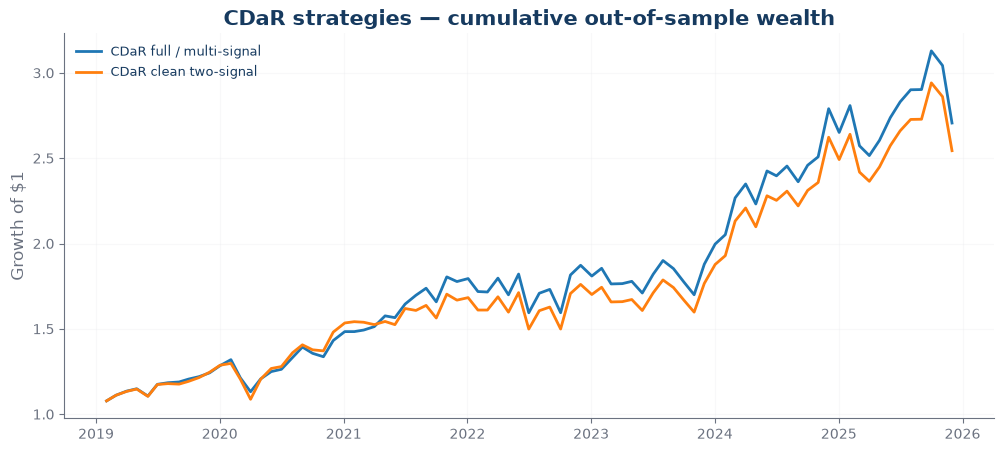

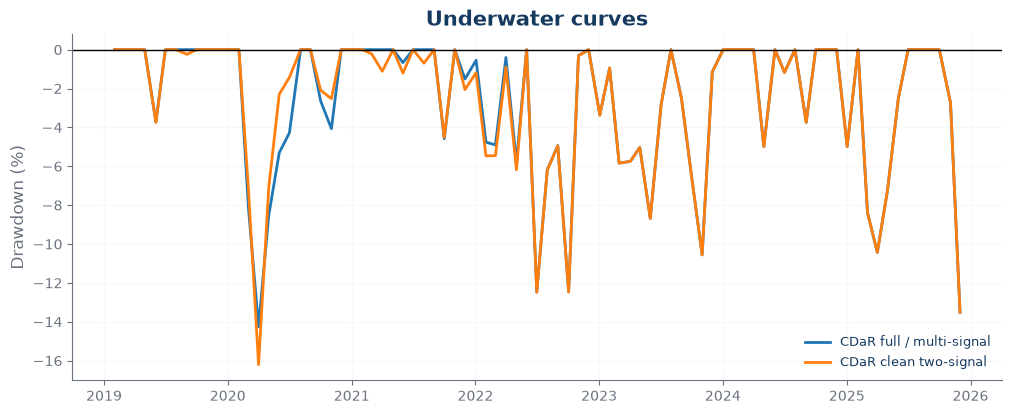

In [41]:
if loaded:
    fig,ax=plt.subplots(figsize=(12,5))
    for label,d in loaded.items():
        r=d["pnl"]["Returns"].dropna().astype(float)
        if len(r) and abs(r.iloc[0])<1e-15: r=r.iloc[1:]
        ax.plot(r.index,(1+r).cumprod(),lw=2,label=label)
    ax.set_ylabel("Growth of $1"); ax.set_title("CDaR strategies — cumulative out-of-sample wealth")
    ax.grid(alpha=.25); ax.legend(); ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y")); plt.show()

    fig,ax=plt.subplots(figsize=(12,4.5))
    for label,d in loaded.items():
        r=d["pnl"]["Returns"].dropna().astype(float)
        if len(r) and abs(r.iloc[0])<1e-15: r=r.iloc[1:]
        ax.plot(r.index,100*drawdown_series(r),lw=2,label=label)
    ax.axhline(0,lw=1,color="black"); ax.set_ylabel("Drawdown (%)"); ax.set_title("Underwater curves")
    ax.grid(alpha=.25); ax.legend(); ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y")); plt.show()


## 4. Rolling risk-adjusted performance

The rolling charts are particularly useful for CDaR because a good full-sample maximum drawdown can hide long periods with persistent underwater risk.

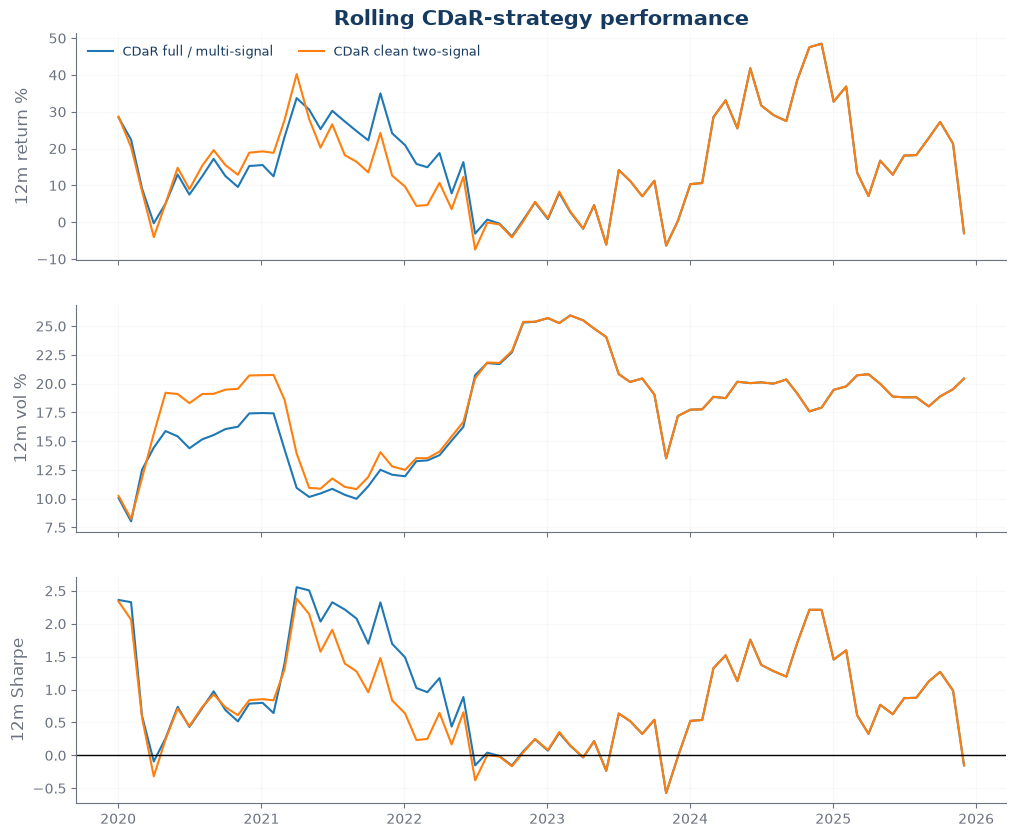

In [42]:
if loaded:
    fig,axes=plt.subplots(3,1,figsize=(12,10),sharex=True)
    for label,d in loaded.items():
        r=d["pnl"]["Returns"].dropna().astype(float)
        if len(r) and abs(r.iloc[0])<1e-15: r=r.iloc[1:]
        roll_ret=(1+r).rolling(ROLL).apply(np.prod,raw=True)-1
        roll_vol=r.rolling(ROLL).std()*np.sqrt(12)
        ex=r-RF/12
        roll_sh=ex.rolling(ROLL).mean()/ex.rolling(ROLL).std()*np.sqrt(12)
        axes[0].plot(r.index,100*roll_ret,label=label)
        axes[1].plot(r.index,100*roll_vol,label=label)
        axes[2].plot(r.index,roll_sh,label=label)
    axes[0].set_ylabel(f"{ROLL}m return %"); axes[1].set_ylabel(f"{ROLL}m vol %"); axes[2].set_ylabel(f"{ROLL}m Sharpe")
    axes[2].axhline(0,color="black",lw=1)
    for a in axes: a.grid(alpha=.25)
    axes[0].legend(ncol=2); axes[0].set_title("Rolling CDaR-strategy performance")
    plt.show()


## 5. Monthly return distribution and calendar heatmap

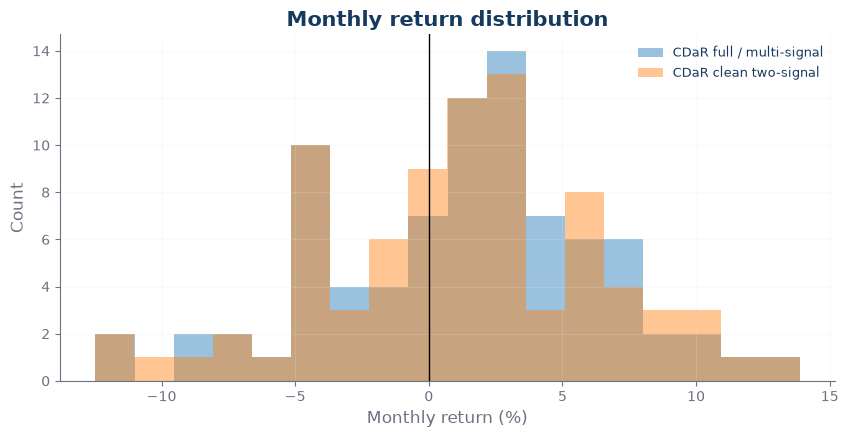

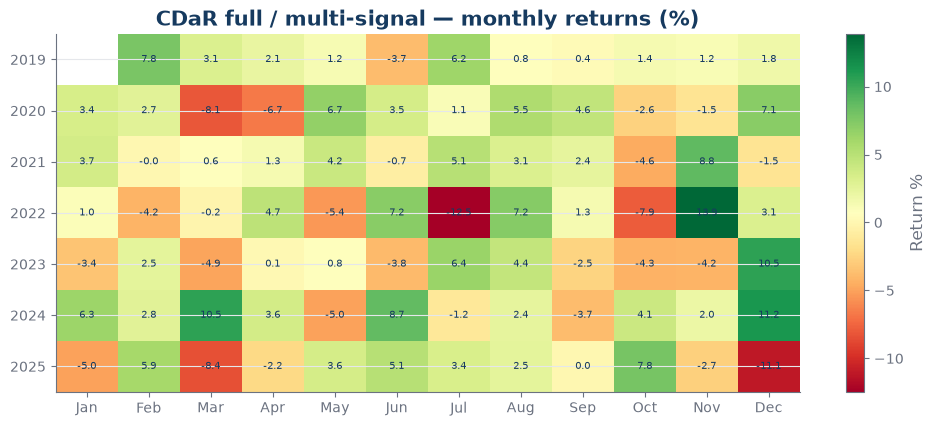

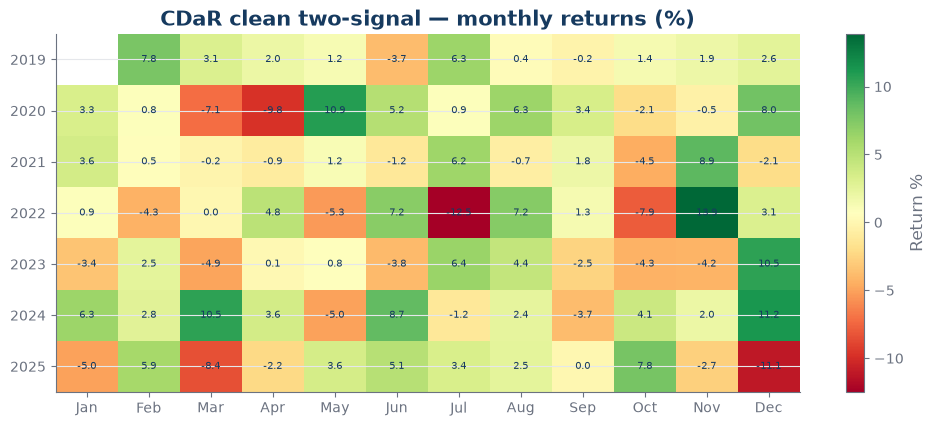

In [43]:
def calendar_matrix(r):
    s=r.dropna().copy();
    if len(s) and abs(s.iloc[0])<1e-15: s=s.iloc[1:]
    df=pd.DataFrame({"r":s,"year":s.index.year,"month":s.index.month})
    return df.pivot(index="year",columns="month",values="r").reindex(columns=range(1,13))

if loaded:
    fig,ax=plt.subplots(figsize=(10,4.5))
    for label,d in loaded.items():
        r=d["pnl"]["Returns"].dropna().astype(float)
        if len(r) and abs(r.iloc[0])<1e-15: r=r.iloc[1:]
        ax.hist(100*r,bins=18,alpha=.45,label=label)
    ax.axvline(0,color="black",lw=1); ax.set_xlabel("Monthly return (%)"); ax.set_ylabel("Count")
    ax.set_title("Monthly return distribution"); ax.legend(); ax.grid(alpha=.2); plt.show()

    # Show one calendar heatmap per arm for readability.
    for label,d in loaded.items():
        M=calendar_matrix(d["pnl"]["Returns"])*100
        fig,ax=plt.subplots(figsize=(12,max(3,0.45*len(M)+1.5)))
        im=ax.imshow(M.to_numpy(),aspect="auto",cmap="RdYlGn")
        ax.set_xticks(range(12),["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
        ax.set_yticks(range(len(M)),M.index.astype(str)); ax.set_title(f"{label} — monthly returns (%)")
        for i in range(len(M)):
            for j in range(12):
                v=M.iloc[i,j]
                if pd.notna(v): ax.text(j,i,f"{v:.1f}",ha="center",va="center",fontsize=7)
        fig.colorbar(im,ax=ax,label="Return %"); plt.show()


## 6. CDaR-specific predictive risk: raw vs centred vs terminal CVaR

This is the central diagnostic that the CVaR notebook did not need. For each monthly decision the pipeline exports both terminal-loss CVaR and path CDaR. `cdar_model_raw` includes the predictive drift path; `cdar_model_centered` removes the cross-scenario mean increment before building the drawdown path.


CDaR full / multi-signal | active forward measure: <ArrowStringArray>
['cdar']
Length: 1, dtype: str


,count,mean,min,25%,50%,75%,max,std
date,83,2022-07-02 08:23:07.951807,2019-02-01 00:00:00,2020-10-17 00:00:00,2022-07-01 00:00:00,2024-03-16 12:00:00,2025-12-01 00:00:00,NaN
cdar_model_raw,83.0,0.06296,0.028418,0.054793,0.065855,0.072369,0.101055,0.018945
cdar_model_centered,83.0,0.103037,0.048686,0.089449,0.110241,0.11871,0.161398,0.029086
cvar_model_centered,83.0,0.121749,0.059001,0.106114,0.129187,0.140304,0.196659,0.034488
vol_model,83.0,0.05913,0.028532,0.050507,0.063595,0.067962,0.09277,0.016722


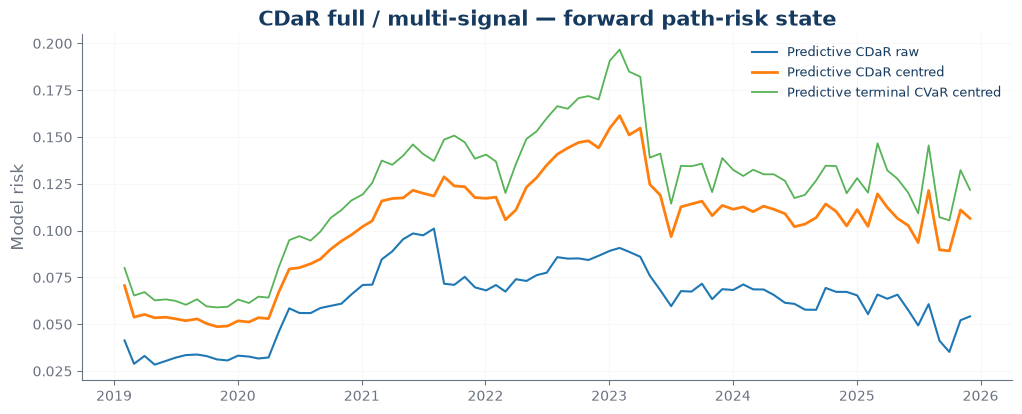

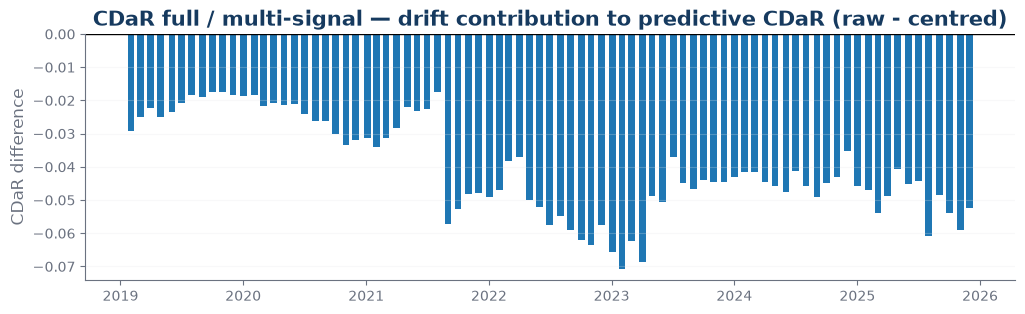


CDaR clean two-signal | active forward measure: <ArrowStringArray>
['cdar']
Length: 1, dtype: str


,count,mean,min,25%,50%,75%,max,std
date,83,2022-07-02 08:23:07.951807,2019-02-01 00:00:00,2020-10-17 00:00:00,2022-07-01 00:00:00,2024-03-16 12:00:00,2025-12-01 00:00:00,NaN
cdar_model_raw,83.0,0.063528,0.028861,0.054793,0.067288,0.073257,0.0912,0.01651
cdar_model_centered,83.0,0.102903,0.051085,0.083739,0.110241,0.120228,0.161396,0.029958
cvar_model_centered,83.0,0.121669,0.059231,0.099387,0.129186,0.142838,0.196659,0.035637
vol_model,83.0,0.059071,0.028864,0.048222,0.063595,0.069152,0.092767,0.017219


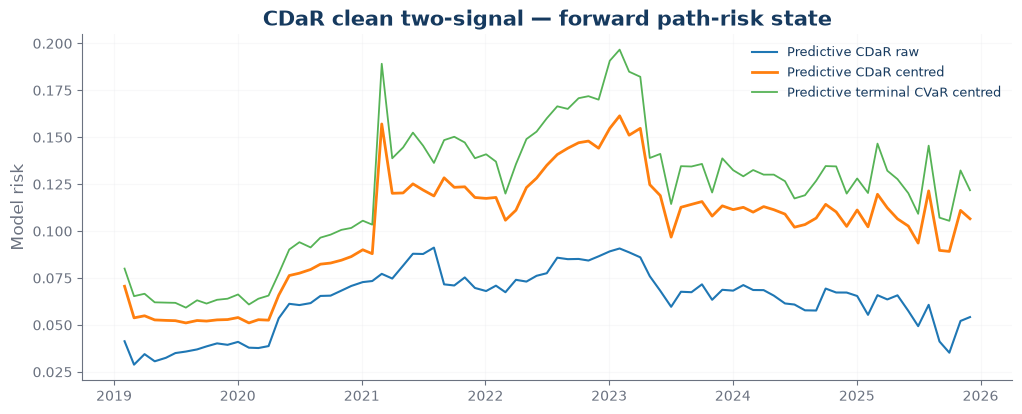

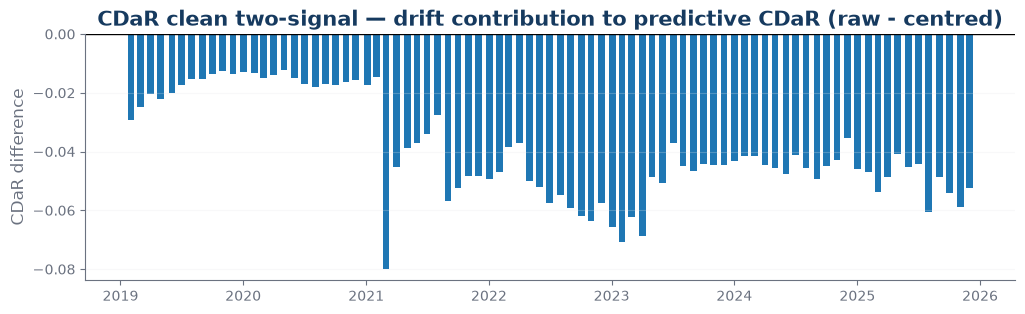

In [44]:
for label,d in loaded.items():
    p=RESULTS/d["folder"]/"forecast_risk.csv"
    if not p.exists():
        print(f"{label}: forecast_risk.csv missing — likely the run stopped before this export.")
        continue
    f=pd.read_csv(p); f["date"]=pd.to_datetime(f["date"])
    numeric=[c for c in f.columns if c not in {"date","forward_risk_measure"}]
    for c in numeric: f[c]=pd.to_numeric(f[c],errors="coerce")
    print(f"\n{label} | active forward measure:", f.get("forward_risk_measure",pd.Series(dtype=str)).dropna().unique())
    cols=[c for c in ["cdar_model_raw","cdar_model_centered","cvar_model_centered","vol_model"] if c in f]
    display(f[["date"]+cols].describe(include="all").T)

    fig,ax=plt.subplots(figsize=(12,4.5))
    if "cdar_model_raw" in f: ax.plot(f.date,f.cdar_model_raw,label="Predictive CDaR raw",lw=1.5)
    if "cdar_model_centered" in f: ax.plot(f.date,f.cdar_model_centered,label="Predictive CDaR centred",lw=2)
    if "cvar_model_centered" in f: ax.plot(f.date,f.cvar_model_centered,label="Predictive terminal CVaR centred",lw=1.3,alpha=.8)
    ax.set_title(f"{label} — forward path-risk state"); ax.set_ylabel("Model risk"); ax.grid(alpha=.25); ax.legend(); plt.show()

    if {"cdar_model_raw","cdar_model_centered"}.issubset(f.columns):
        gap=f["cdar_model_raw"]-f["cdar_model_centered"]
        fig,ax=plt.subplots(figsize=(12,3.2)); ax.bar(f.date,gap,width=20)
        ax.axhline(0,color="black",lw=1); ax.set_title(f"{label} — drift contribution to predictive CDaR (raw - centred)")
        ax.set_ylabel("CDaR difference"); ax.grid(axis="y",alpha=.25); plt.show()


## 7. CDaR timer, backward volatility timer, and executed exposure

For the clean two-signal YAML, the two economically relevant timers are `backward_vol_timer` and `forward_cdar_timer`. For the full multi-signal arm, `overlay_fraction` can additionally reflect conviction/quality logic.

,backward_vol_timer,forward_cdar_timer,forward_risk_timer,conviction_timer,overlay_fraction,target_risky_exposure
backward_vol_timer,1.000,NaN,NaN,0.404,0.994,0.994
forward_cdar_timer,NaN,NaN,NaN,NaN,NaN,NaN
forward_risk_timer,NaN,NaN,NaN,NaN,NaN,NaN
conviction_timer,0.404,NaN,NaN,1.000,0.457,0.457
overlay_fraction,0.994,NaN,NaN,0.457,1.000,1.000
target_risky_exposure,0.994,NaN,NaN,0.457,1.000,1.000


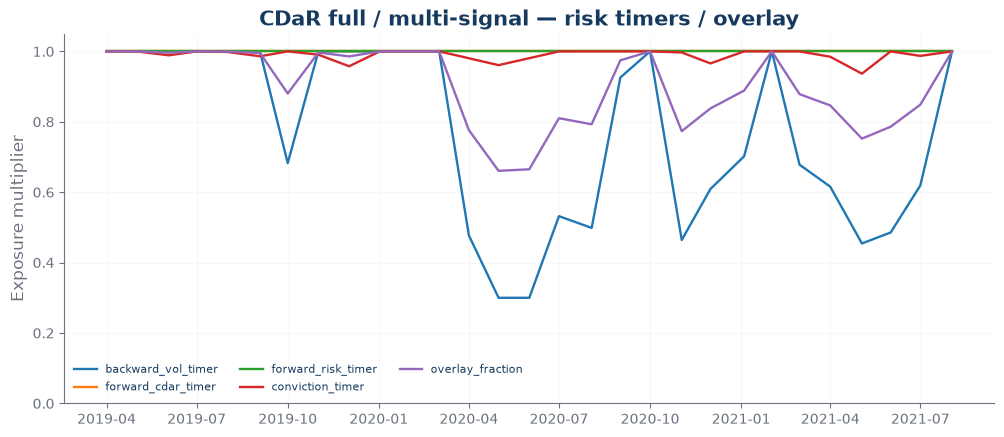

,backward_vol_timer,forward_cdar_timer,forward_risk_timer,conviction_timer,overlay_fraction,target_risky_exposure
backward_vol_timer,1.000,NaN,NaN,0.366,1.000,-0.093
forward_cdar_timer,NaN,NaN,NaN,NaN,NaN,NaN
forward_risk_timer,NaN,NaN,NaN,NaN,NaN,NaN
conviction_timer,0.366,NaN,NaN,1.000,0.366,-0.037
overlay_fraction,1.000,NaN,NaN,0.366,1.000,-0.093
target_risky_exposure,-0.093,NaN,NaN,-0.037,-0.093,1.000


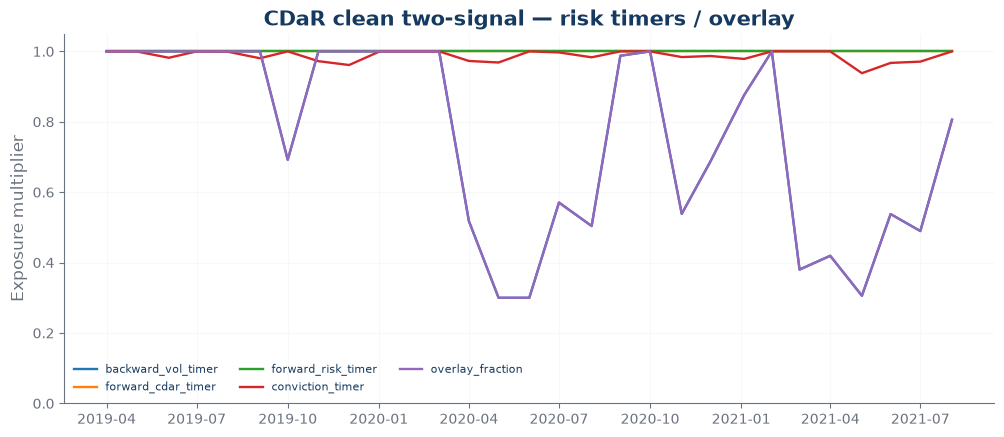

In [45]:
for label,d in loaded.items():
    folder=RESULTS/d["folder"]
    p=folder/"forecast_risk.csv"
    if not p.exists(): continue
    f=pd.read_csv(p); f["date"]=pd.to_datetime(f["date"])
    timers=[c for c in ["backward_vol_timer","forward_cdar_timer","forward_risk_timer","conviction_timer","overlay_fraction","target_risky_exposure"] if c in f]
    for c in timers: f[c]=pd.to_numeric(f[c],errors="coerce")
    if not timers: continue
    display(f[timers].corr().round(3))
    fig,ax=plt.subplots(figsize=(12,4.8))
    for c in timers:
        if c=="target_risky_exposure": continue
        ax.plot(f.date,f[c],label=c,lw=1.7)
    ax.set_ylim(0,1.05); ax.set_ylabel("Exposure multiplier"); ax.set_title(f"{label} — risk timers / overlay")
    ax.grid(alpha=.25); ax.legend(ncol=3,fontsize=8); plt.show()


## 8. Does the CDaR signal lead future realized downside?

This is a descriptive lead test, not causal proof. The next-month return downside proxy is intentionally simple; the repository's `signal_research/` artifacts should be used for the full forecast-error and nested admission tests.

CDaR full / multi-signal corr(forward CDaR, next downside)= -0.27 corr(timer, next downside)= nan


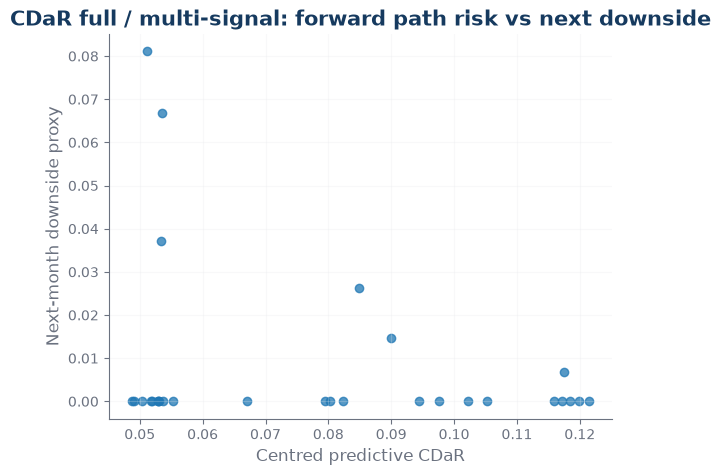

CDaR clean two-signal corr(forward CDaR, next downside)= -0.198 corr(timer, next downside)= nan


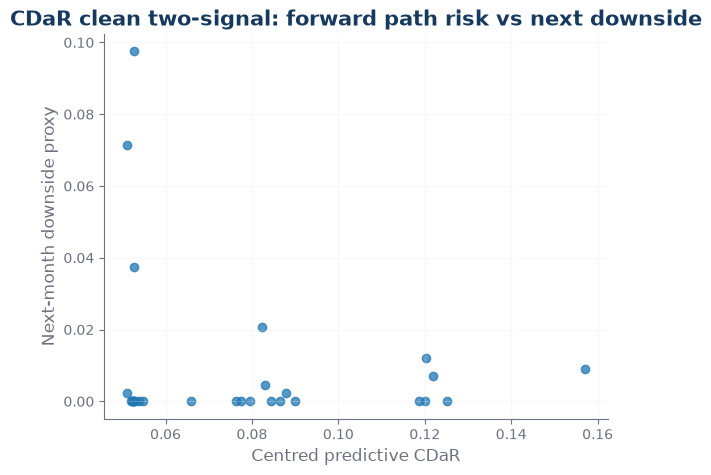

In [46]:
for label,d in loaded.items():
    p=RESULTS/d["folder"]/"forecast_risk.csv"
    if not p.exists(): continue
    f=pd.read_csv(p); f["date"]=pd.to_datetime(f["date"]); f=f.set_index("date")
    pnl=d["pnl"]
    x=pd.DataFrame(index=f.index)
    x["forward_cdar"] = pd.to_numeric(f.get("cdar_model_centered"),errors="coerce")
    x["cdar_timer"] = pd.to_numeric(f.get("forward_cdar_timer"),errors="coerce")
    x["next_return"] = pnl["Returns"].reindex(x.index).shift(-1)
    x["next_downside"] = (-x["next_return"]).clip(lower=0)
    x=x.dropna()
    if len(x)<6: continue
    print(label, "corr(forward CDaR, next downside)=", round(x.forward_cdar.corr(x.next_downside),3),
          "corr(timer, next downside)=", round(x.cdar_timer.corr(x.next_downside),3) if x.cdar_timer.notna().sum()>2 else np.nan)
    fig,ax=plt.subplots(figsize=(6.5,5))
    ax.scatter(x.forward_cdar,x.next_downside,alpha=.75)
    ax.set_xlabel("Centred predictive CDaR"); ax.set_ylabel("Next-month downside proxy")
    ax.set_title(f"{label}: forward path risk vs next downside"); ax.grid(alpha=.25); plt.show()


## 9. Portfolio composition, concentration, active holdings and turnover


CDaR full / multi-signal: active mean=109.7, effective N mean=12.9, one-way turnover mean=0.106, median=0.096


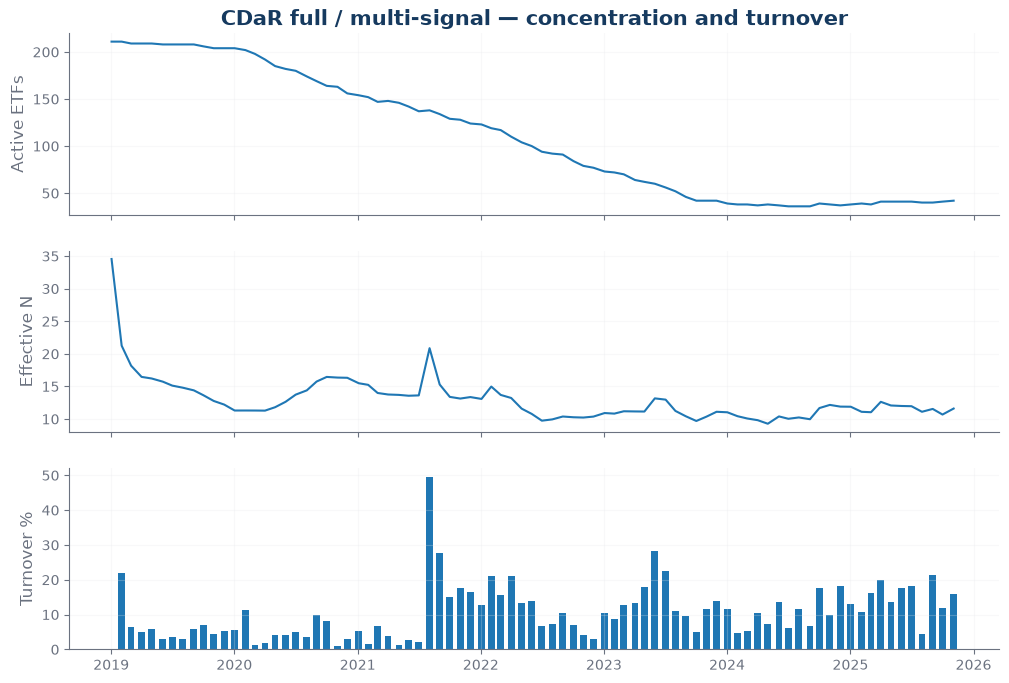

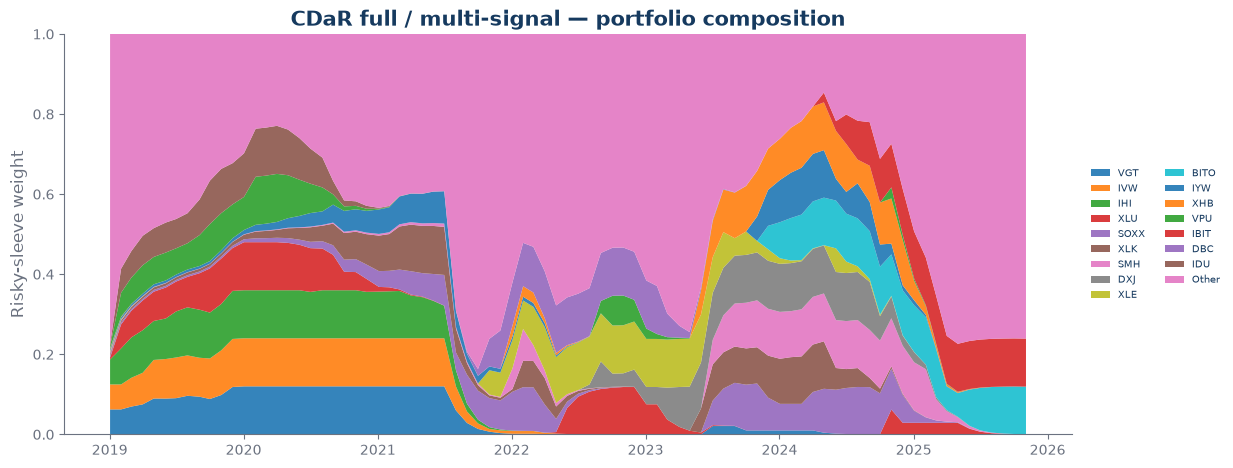


CDaR clean two-signal: active mean=137.2, effective N mean=15.4, one-way turnover mean=0.096, median=0.094


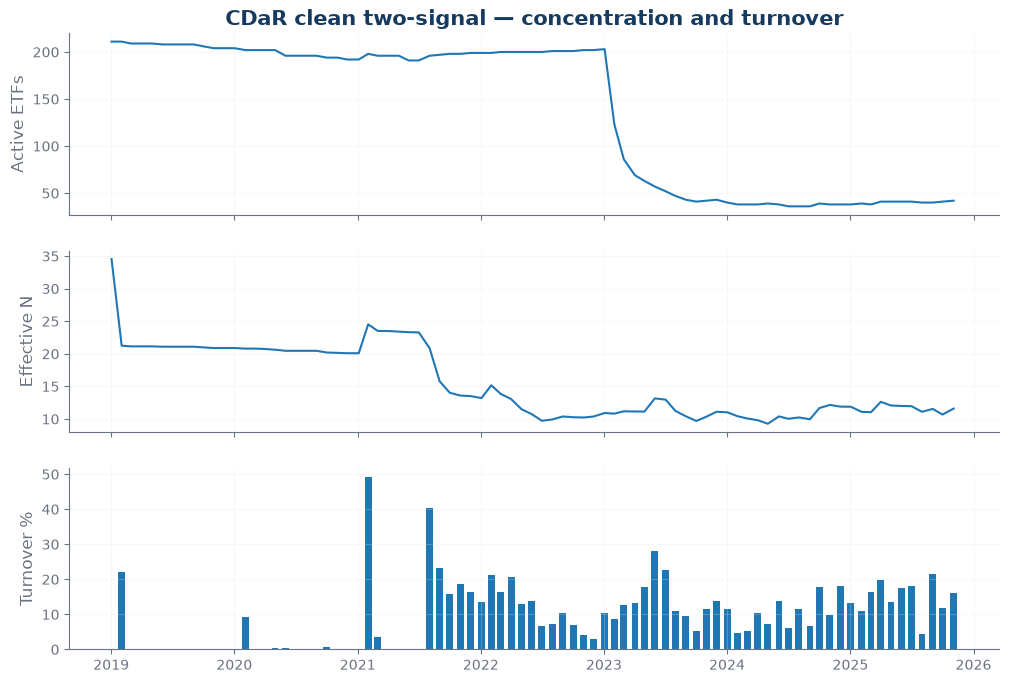

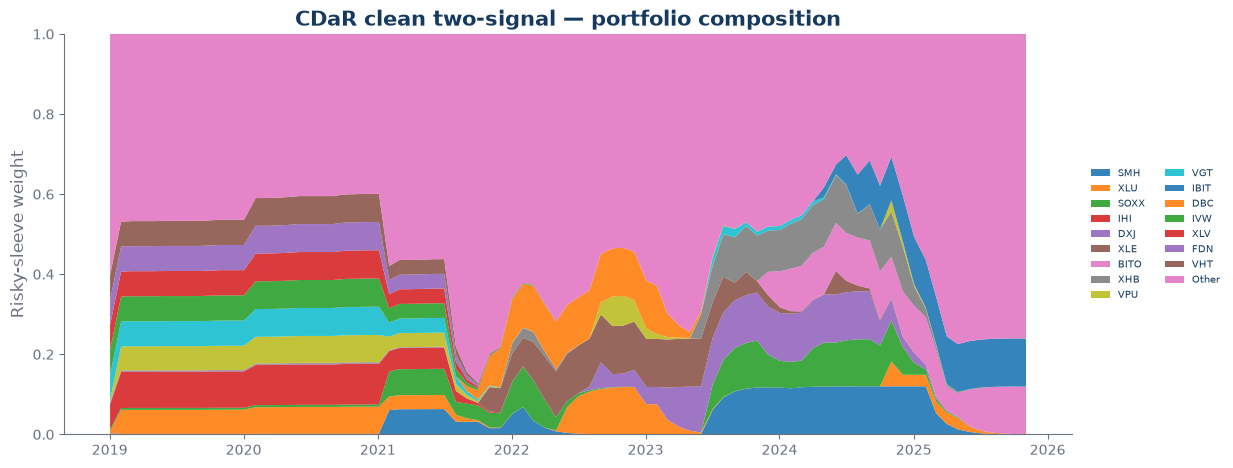

In [47]:
def comp_matrix(weights):
    if not weights: return pd.DataFrame()
    months=sorted(weights); cols=sorted({x for w in weights.values() for x in w.index})
    M=pd.DataFrame(0.0,index=months,columns=cols)
    for dt,w in weights.items(): M.loc[dt,w.index]=w.values
    return M

def one_way_turnover(weights):
    months=sorted(weights); out={}
    for i in range(1,len(months)):
        a,b=weights[months[i-1]],weights[months[i]]; ix=a.index.union(b.index)
        out[months[i]]=0.5*float(np.abs(a.reindex(ix).fillna(0)-b.reindex(ix).fillna(0)).sum())
    return pd.Series(out)

for label,d in loaded.items():
    W=d["weights"]
    if not W:
        print(label,": weights.xlsx unavailable")
        continue
    M=comp_matrix(W)
    active=(M>1e-9).sum(axis=1); hhi=(M**2).sum(axis=1); neff=1/hhi.replace(0,np.nan)
    to=one_way_turnover(W)
    print(f"\n{label}: active mean={active.mean():.1f}, effective N mean={neff.mean():.1f}, one-way turnover mean={to.mean():.3f}, median={to.median():.3f}")

    fig,axes=plt.subplots(3,1,figsize=(12,8),sharex=True)
    axes[0].plot(active.index,active.values); axes[0].set_ylabel("Active ETFs")
    axes[1].plot(neff.index,neff.values); axes[1].set_ylabel("Effective N")
    axes[2].bar(to.index,100*to.values,width=20); axes[2].set_ylabel("Turnover %")
    for a in axes: a.grid(alpha=.25)
    axes[0].set_title(f"{label} — concentration and turnover"); plt.show()

    keep=list(M.sum().sort_values(ascending=False).head(TOP_K).index)
    other=[c for c in M.columns if c not in keep]
    P=M[keep].copy();
    if other: P["Other"]=M[other].sum(axis=1)
    fig,ax=plt.subplots(figsize=(13,5.2))
    ax.stackplot(P.index,[P[c].values for c in P.columns],labels=P.columns,alpha=.9)
    ax.set_ylim(0,1); ax.set_ylabel("Risky-sleeve weight"); ax.set_title(f"{label} — portfolio composition")
    ax.legend(loc="center left",bbox_to_anchor=(1.01,.5),fontsize=7,ncol=2); ax.grid(False); plt.show()


## 10. Partial execution and realized trading state

CDaR full / multi-signal execution alpha: {'count': 84.0, 'mean': 0.6587, 'std': 0.239, 'min': 0.0, '25%': 0.5091, '50%': 0.5283, '75%': 1.0, 'max': 1.0}


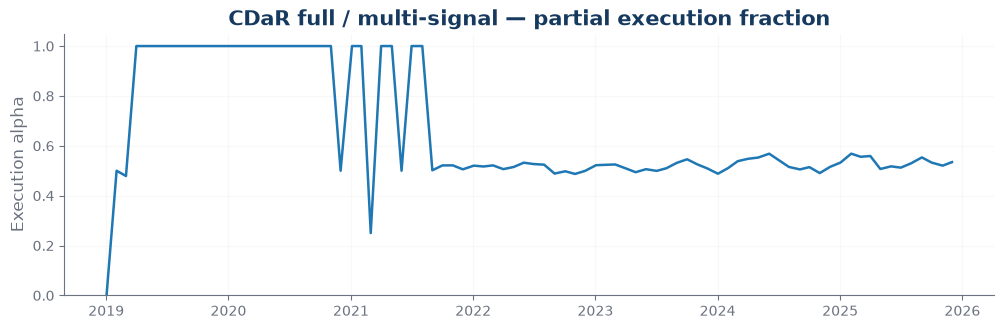

CDaR clean two-signal execution alpha: {'count': 84.0, 'mean': 0.6288, 'std': 0.2253, 'min': 0.0, '25%': 0.5052, '50%': 0.523, '75%': 0.6763, 'max': 1.0}


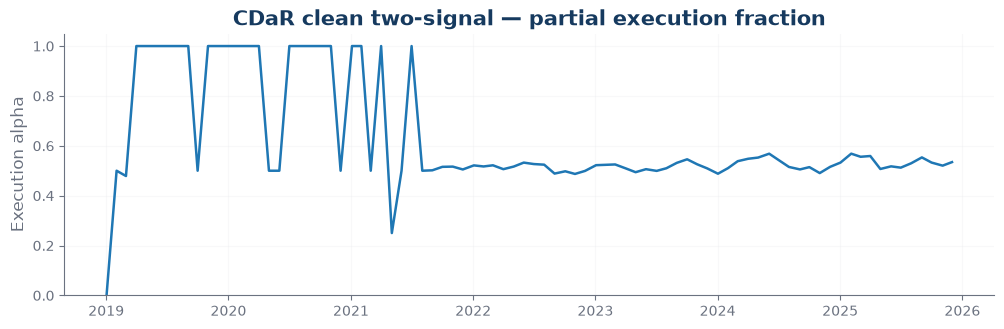

In [48]:
for label,d in loaded.items():
    pnl=d["pnl"]
    if "Alpha" not in pnl: continue
    a=pnl["Alpha"].dropna()
    if len(a)==0: continue
    print(label, "execution alpha:", a.describe().round(4).to_dict())
    fig,ax=plt.subplots(figsize=(12,3.4)); ax.plot(a.index,a.values,lw=1.8)
    ax.set_ylim(0,1.05); ax.set_ylabel("Execution alpha"); ax.set_title(f"{label} — partial execution fraction")
    ax.grid(alpha=.25); plt.show()


## 11. Dynamic optimizer/controller state

For the CDaR optimizer, the dynamic confidence state is interpreted as the current tail-confidence control used by the framework; the path-risk budget and CDaR alpha are also available through run metadata/configuration.


 CDaR full / multi-signal


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,83,NaN,NaN,NaN,2022-06-01 22:15:54.216867,2019-01-02 00:00:00,2020-09-16 00:00:00,2022-06-01 00:00:00,2024-02-15 12:00:00,2025-11-03 00:00:00,NaN
dynamic_enabled,83,1,True,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
performance_score,83.0,NaN,NaN,NaN,0.212058,-0.337067,0.020235,0.219783,0.405158,0.673687,0.244353
streak,83.0,NaN,NaN,NaN,1.253012,-3.0,-1.0,1.0,2.5,8.0,2.289123
ewma_return,83.0,NaN,NaN,NaN,0.017598,-0.014275,0.007588,0.017694,0.024296,0.077851,0.015895
ewma_vol,83.0,NaN,NaN,NaN,0.054299,0.001,0.046371,0.053821,0.06407,0.094606,0.015018
total_score,83.0,NaN,NaN,NaN,0.167441,-0.47011,-0.044194,0.198932,0.389445,0.615,0.27109
confidence_level,83.0,NaN,NaN,NaN,0.952512,0.942948,0.949337,0.952984,0.955842,0.959225,0.004066
turnover_penalty,83.0,NaN,NaN,NaN,0.01,0.01,0.01,0.01,0.01,0.01,0.0
regime_score,83.0,NaN,NaN,NaN,0.063333,-1.0,-0.196469,0.204753,0.359293,0.703266,0.416806


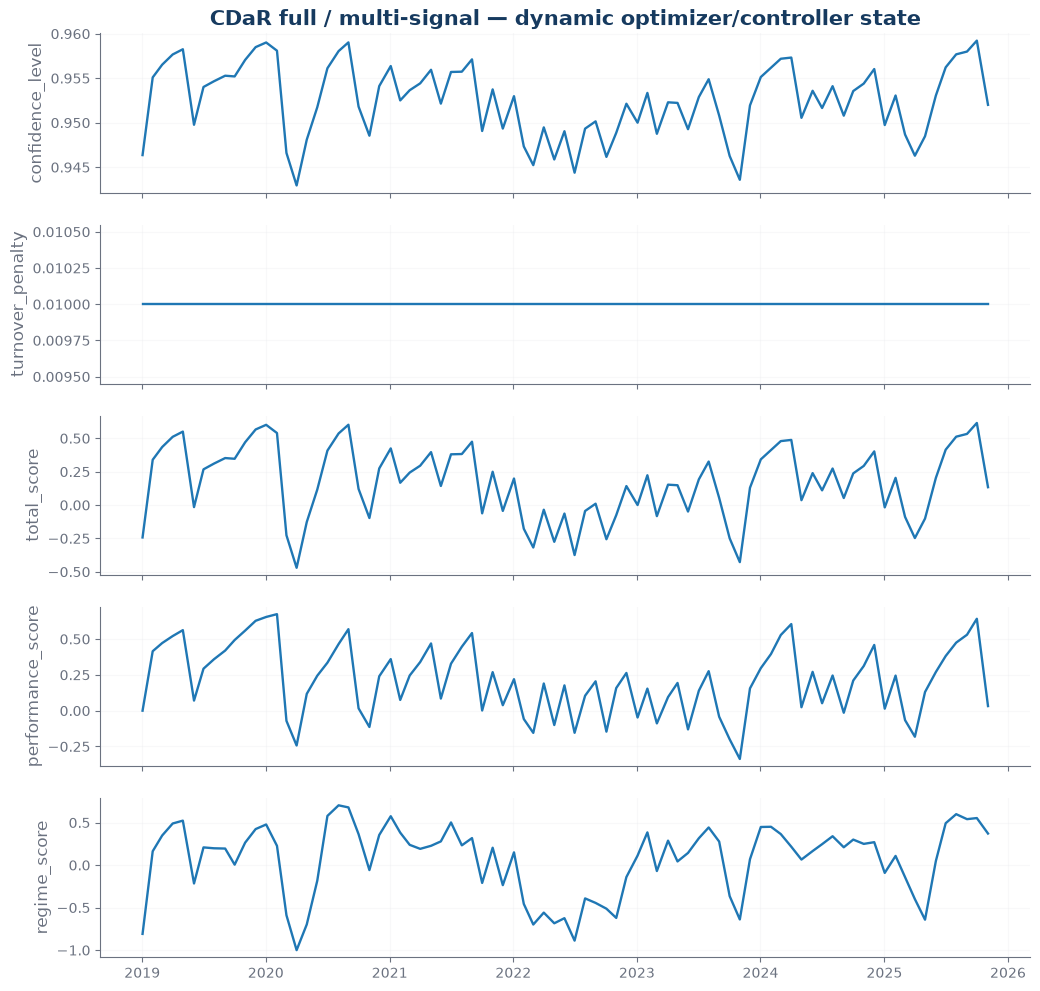


 CDaR clean two-signal


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,83,NaN,NaN,NaN,2022-06-01 22:15:54.216867,2019-01-02 00:00:00,2020-09-16 00:00:00,2022-06-01 00:00:00,2024-02-15 12:00:00,2025-11-03 00:00:00,NaN
dynamic_enabled,83,1,True,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
performance_score,83.0,NaN,NaN,NaN,0.181867,-0.337298,0.007059,0.19277,0.340659,0.641381,0.22764
streak,83.0,NaN,NaN,NaN,0.963855,-3.0,-1.0,1.0,2.0,6.0,2.002716
ewma_return,83.0,NaN,NaN,NaN,0.016923,-0.017276,0.007481,0.016665,0.024121,0.077851,0.016267
ewma_vol,83.0,NaN,NaN,NaN,0.056178,0.001,0.047923,0.055105,0.064677,0.094729,0.014564
total_score,83.0,NaN,NaN,NaN,0.146307,-0.489734,-0.047976,0.147945,0.334611,0.614999,0.258364
confidence_level,83.0,NaN,NaN,NaN,0.952195,0.942654,0.94928,0.952219,0.955019,0.959225,0.003875
turnover_penalty,83.0,NaN,NaN,NaN,0.01,0.01,0.01,0.01,0.01,0.01,0.0
regime_score,83.0,NaN,NaN,NaN,0.063333,-1.0,-0.196469,0.204753,0.359293,0.703266,0.416806


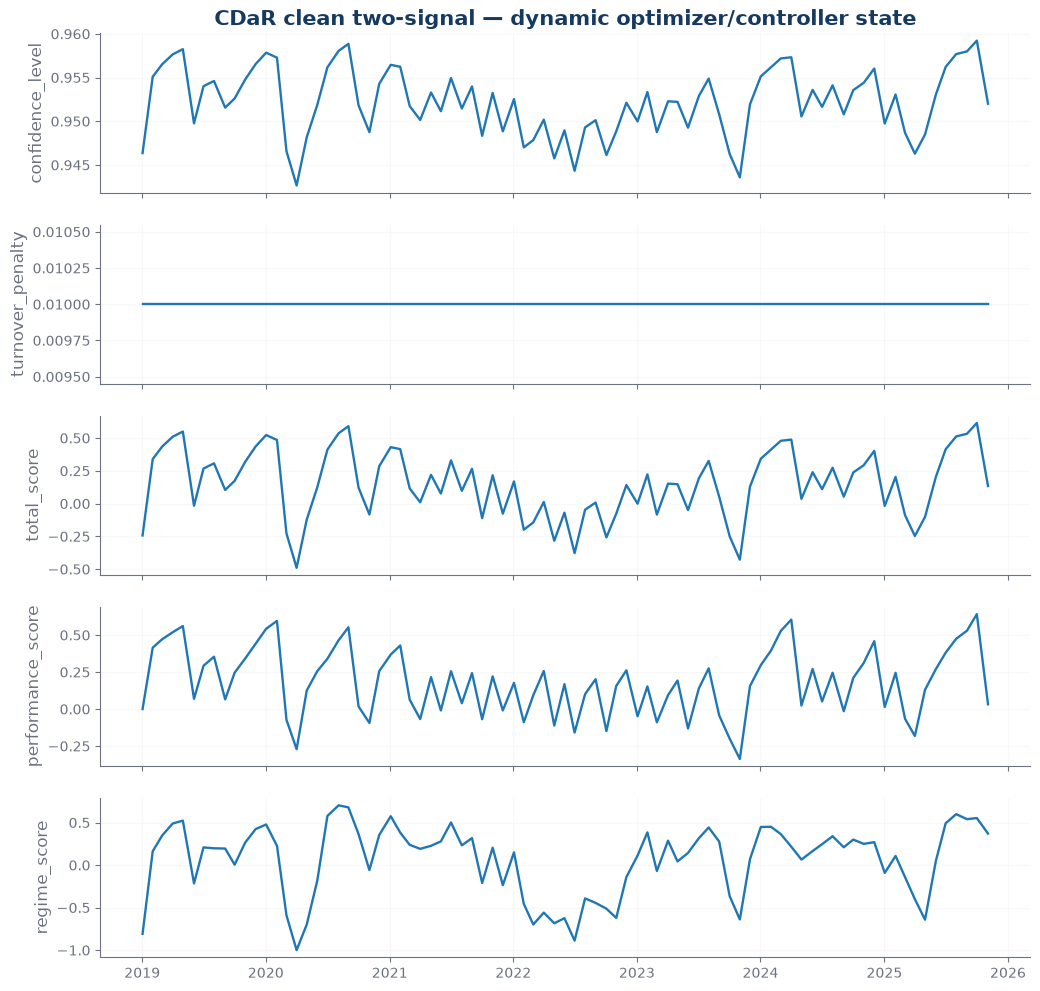

In [49]:
for label,d in loaded.items():
    p=RESULTS/d["folder"]/"dynamic_parameter_history.csv"
    if not p.exists():
        print(label,": no dynamic_parameter_history.csv")
        continue
    h=pd.read_csv(p)
    if "date" in h: h["date"]=pd.to_datetime(h["date"])
    print("\n",label); display(h.describe(include="all").T)
    candidates=[c for c in ["confidence_level","turnover_penalty","total_score","performance_score","regime_score"] if c in h]
    if not candidates: continue
    fig,axes=plt.subplots(len(candidates),1,figsize=(12,2.4*len(candidates)),sharex=True)
    axes=np.atleast_1d(axes)
    for ax,c in zip(axes,candidates):
        ax.plot(h["date"],pd.to_numeric(h[c],errors="coerce"),lw=1.7); ax.set_ylabel(c); ax.grid(alpha=.25)
    axes[0].set_title(f"{label} — dynamic optimizer/controller state"); plt.show()


## 12. Predictive-model diagnostics

,count,mean,min,25%,50%,75%,max,std
date,84,2022-06-17 03:25:42.857142,2019-01-02 00:00:00,2020-09-23 12:00:00,2022-06-16 00:00:00,2024-03-08 18:00:00,2025-12-01 00:00:00,NaN
log_score,84.0,1.075926,-9.63406,0.826525,1.297726,1.693525,2.239877,1.36034
predictive_deviance_proxy,84.0,-513.409709,-976.586342,-802.593236,-639.788793,-412.492795,4354.594974,621.885231
rank_ic,84.0,0.04985,-0.482666,-0.131425,0.044509,0.241046,0.659449,0.269839
mae,84.0,0.048273,0.0,0.032665,0.04499,0.054659,0.171927,0.023522
coverage_95,84.0,0.868141,0.0,0.851192,0.918988,0.964471,0.995726,0.169213
sign_precision,84.0,0.516191,0.0,0.423748,0.517656,0.622117,0.793522,0.133981
avg_true_positives,84.0,0.596246,0.0,0.259425,0.714533,0.876873,0.990783,0.327448
r_squared,84.0,-1.830314,-4.809848,-2.561679,-1.734613,-0.837313,0.040935,1.171273
rmse,84.0,0.064495,0.0,0.047831,0.0591,0.073217,0.209266,0.02792


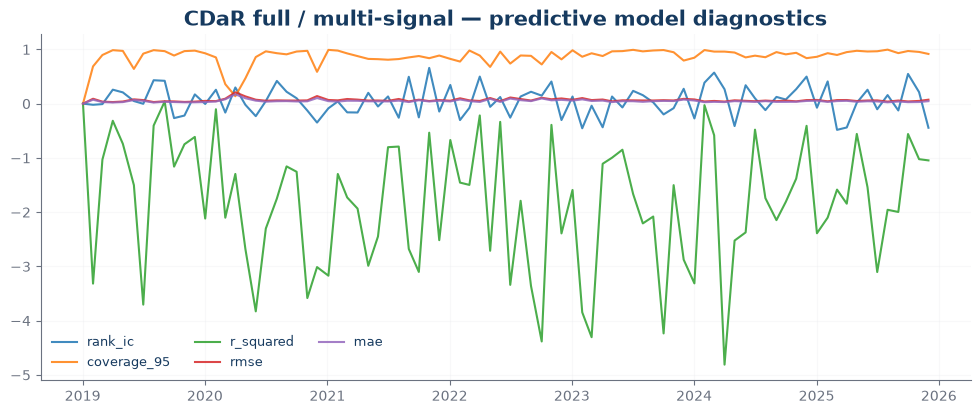

,count,mean,min,25%,50%,75%,max,std
date,84,2022-06-17 03:25:42.857142,2019-01-02 00:00:00,2020-09-23 12:00:00,2022-06-16 00:00:00,2024-03-08 18:00:00,2025-12-01 00:00:00,NaN
log_score,84.0,1.075926,-9.63406,0.826525,1.297726,1.693525,2.239877,1.36034
predictive_deviance_proxy,84.0,-513.409709,-976.586342,-802.593236,-639.788793,-412.492795,4354.594974,621.885231
rank_ic,84.0,0.04985,-0.482666,-0.131425,0.044509,0.241046,0.659449,0.269839
mae,84.0,0.048273,0.0,0.032665,0.04499,0.054659,0.171927,0.023522
coverage_95,84.0,0.868141,0.0,0.851192,0.918988,0.964471,0.995726,0.169213
sign_precision,84.0,0.516191,0.0,0.423748,0.517656,0.622117,0.793522,0.133981
avg_true_positives,84.0,0.596246,0.0,0.259425,0.714533,0.876873,0.990783,0.327448
r_squared,84.0,-1.830314,-4.809848,-2.561679,-1.734613,-0.837313,0.040935,1.171273
rmse,84.0,0.064495,0.0,0.047831,0.0591,0.073217,0.209266,0.02792


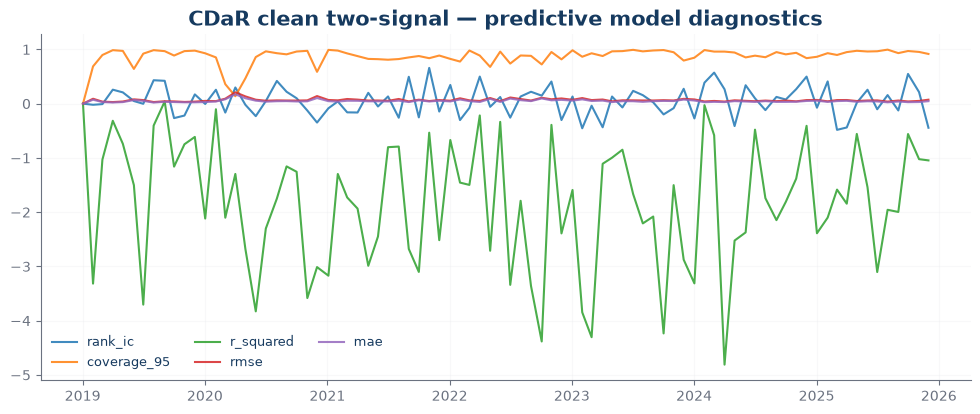

In [50]:
for label,d in loaded.items():
    p=RESULTS/d["folder"]/"model.csv"
    if not p.exists(): continue
    m=pd.read_csv(p); first=m.columns[0]; m[first]=pd.to_datetime(m[first],errors="coerce"); m=m.rename(columns={first:"date"})
    for c in m.columns[1:]: m[c]=pd.to_numeric(m[c],errors="coerce")
    display(m.describe().T)
    cols=[c for c in ["rank_ic","coverage_95","r_squared","rmse","mae"] if c in m]
    if cols:
        fig,ax=plt.subplots(figsize=(12,4.5))
        for c in cols: ax.plot(m.date,m[c],label=c,alpha=.85)
        ax.set_title(f"{label} — predictive model diagnostics"); ax.grid(alpha=.25); ax.legend(ncol=3); plt.show()


## 13. Nested walk-forward selection and research trial ledger

In [51]:
for label,d in loaded.items():
    base=RESULTS/d["folder"]
    for name in ["selection_audit.csv","trial_audit.csv"]:
        p=base/name
        if not p.exists():
            print(f"{label}: {name} missing")
            continue
        x=pd.read_csv(p)
        print(f"\n{label} — {name}: rows={len(x)}, columns={len(x.columns)}")
        display(x.head())
        if name=="trial_audit.csv" and "selected_candidate" in x:
            print("Selected candidate count:", x["selected_candidate"].astype(str).str.lower().eq("true").sum())
            if "stage" in x: display(x["stage"].value_counts(dropna=False).to_frame("count"))



CDaR full / multi-signal — selection_audit.csv: rows=83, columns=29


,date,engine_used,fallback_reason,selected_alpha,mode,train_rows,validation_rows,test_rows,history_start,history_end,train_start_timestamp,train_end,validation_start,validation_end,internal_test_start,internal_test_end,train_n_obs,validation_n_obs,internal_test_n_obs,robust_selection_score,candidate_attempt_records,failed_candidate_attempts,selected_candidate_id,selected_source,selected_method,selected_params,target_risky_exposure,validation_best,test_best
0,2019-01-02,False,"""['BOND'] not in index""",0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,False,"""['BOND'] not in index""",0.478756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03-01,True,NaN,1.000000,row_fallback,188.0,424.0,141.0,39.0,791.0,39.0,226.0,227.0,650.0,651.0,791.0,188.0,424.0,141.0,0.167465,[],0.0,hold_current:hold_current:candidate=1:alpha=1....,hold_current,hold_current,"{""type"": ""hold_current""}",1.000000,"[{""candidate_id"": ""hold_current:hold_current:c...","[{""candidate_id"": ""hold_current:hold_current:c..."
3,2019-04-01,True,NaN,1.000000,row_fallback,188.0,422.0,141.0,62.0,812.0,62.0,249.0,250.0,671.0,672.0,812.0,188.0,422.0,141.0,0.178723,[],0.0,hold_current:hold_current:candidate=1:alpha=1....,hold_current,hold_current,"{""type"": ""hold_current""}",1.000000,"[{""candidate_id"": ""hold_current:hold_current:c...","[{""candidate_id"": ""hold_current:hold_current:c..."
4,2019-05-01,True,NaN,1.000000,row_fallback,188.0,423.0,141.0,83.0,834.0,83.0,270.0,271.0,693.0,694.0,834.0,188.0,423.0,141.0,0.190642,[],0.0,hold_current:hold_current:candidate=1:alpha=1....,hold_current,hold_current,"{""type"": ""hold_current""}",0.996266,"[{""candidate_id"": ""hold_current:hold_current:c...","[{""candidate_id"": ""hold_current:hold_current:c..."



CDaR full / multi-signal — trial_audit.csv: rows=348, columns=23


,rebalance_date,stage,recipe_id,selected_candidate,candidate_id,source,method,params,alpha,target_weights,executed_weights,turnover,validation_total_return,validation_sharpe,validation_volatility,validation_score,validation_n_obs,test_total_return,test_sharpe,test_volatility,test_score,test_n_obs,robust_selection_score
0,2019-03-01,validation,53a1e08148ed8bc7,False,hold_current:hold_current:candidate=1:alpha=0....,hold_current,hold_current,"{""type"": ""hold_current""}",0.75,"{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...","{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...",1.758576e-16,0.374479,2.095672,0.092276,0.479262,424,NaN,NaN,NaN,NaN,0,NaN
1,2019-03-01,validation,1e05e0d21c28ce0c,True,hold_current:hold_current:candidate=1:alpha=1....,hold_current,hold_current,"{""type"": ""hold_current""}",1.00,"{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...","{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...",1.966743e-16,0.374479,2.095672,0.092276,0.479262,424,NaN,NaN,NaN,NaN,0,NaN
2,2019-03-01,validation,387b37d647398ef4,False,hold_current:hold_current:candidate=1:alpha=0....,hold_current,hold_current,"{""type"": ""hold_current""}",0.50,"{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...","{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...",1.971080e-16,0.374479,2.095672,0.092276,0.479262,424,NaN,NaN,NaN,NaN,0,NaN
3,2019-03-01,validation,ecd0cc1f3b8afa0c,False,hold_current:hold_current:candidate=1:alpha=0....,hold_current,hold_current,"{""type"": ""hold_current""}",0.25,"{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...","{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...",1.966743e-16,0.374479,2.095672,0.092276,0.479262,424,NaN,NaN,NaN,NaN,0,NaN
4,2019-03-01,validation,466c059fc22b4e27,False,optimizer:return_cdar_constraint:candidate=0:a...,optimizer,return_cdar_constraint,"{""cdar_budget_mult"": 1.0, ""cdar_confidence_lev...",0.25,"{""AAXJ"": 0.0, ""ACWI"": 0.0, ""ACWX"": 0.0, ""AGG"":...","{""AAXJ"": 0.0009286758096044498, ""ACWI"": 0.0009...",4.568417e-01,0.341178,1.915814,0.093379,0.427832,424,NaN,NaN,NaN,NaN,0,NaN


Selected candidate count: 58


...

,date,engine_used,fallback_reason,selected_alpha,mode,train_rows,validation_rows,test_rows,history_start,history_end,train_start_timestamp,train_end,validation_start,validation_end,internal_test_start,internal_test_end,train_n_obs,validation_n_obs,internal_test_n_obs,robust_selection_score,candidate_attempt_records,failed_candidate_attempts,selected_candidate_id,selected_source,selected_method,selected_params,target_risky_exposure,validation_best,test_best,optimizer_lp_success,optimizer_risk_measure,optimizer_cdar_level,optimizer_cdar_budget,optimizer_cdar_value,optimizer_cdar_constraint_slack,optimizer_cdar_constraint_binding,optimizer_cdar_budget_dual_scipy_min,optimizer_cdar_budget_shadow_price_max,optimizer_objective_expected_return,optimizer_target_turnover_l1,optimizer_scenario_paths,optimizer_path_horizon
0,2019-01-02,False,"""['BOND'] not in index""",0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,False,"""['BOND'] not in index""",0.478756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03-01,True,NaN,1.000000,row_fallback,188.0,424.0,141.0,39.0,791.0,39.0,226.0,227.0,650.0,651.0,791.0,188.0,424.0,141.0,0.167465,[],0.0,hold_current:hold_current:candidate=1:alpha=1....,hold_current,hold_current,"{""type"": ""hold_current""}",1.0,"[{""candidate_id"": ""hold_current:hold_current:c...","[{""candidate_id"": ""hold_current:hold_current:c...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-04-01,True,NaN,1.000000,row_fallback,188.0,422.0,141.0,62.0,812.0,62.0,249.0,250.0,671.0,672.0,812.0,188.0,422.0,141.0,0.167658,[],0.0,hold_current:hold_current:candidate=1:alpha=1....,hold_current,hold_current,"{""type"": ""hold_current""}",1.0,"[{""candidate_id"": ""hold_current:hold_current:c...","[{""candidate_id"": ""hold_current:hold_current:c...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-05-01,True,NaN,1.000000,row_fallback,188.0,423.0,141.0,83.0,834.0,83.0,270.0,271.0,693.0,694.0,834.0,188.0,423.0,141.0,0.172461,[],0.0,hold_current:hold_current:candidate=1:alpha=1....,hold_current,hold_current,"{""type"": ""hold_current""}",1.0,"[{""candidate_id"": ""hold_current:hold_current:c...","[{""candidate_id"": ""hold_current:hold_current:c...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



CDaR clean two-signal — trial_audit.csv: rows=348, columns=23


,rebalance_date,stage,recipe_id,selected_candidate,candidate_id,source,method,params,alpha,target_weights,executed_weights,turnover,validation_total_return,validation_sharpe,validation_volatility,validation_score,validation_n_obs,test_total_return,test_sharpe,test_volatility,test_score,test_n_obs,robust_selection_score
0,2019-03-01,validation,53a1e08148ed8bc7,False,hold_current:hold_current:candidate=1:alpha=0....,hold_current,hold_current,"{""type"": ""hold_current""}",0.75,"{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...","{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...",1.758576e-16,0.374479,2.095672,0.092276,0.479262,424,NaN,NaN,NaN,NaN,0,NaN
1,2019-03-01,validation,1e05e0d21c28ce0c,True,hold_current:hold_current:candidate=1:alpha=1....,hold_current,hold_current,"{""type"": ""hold_current""}",1.00,"{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...","{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...",1.966743e-16,0.374479,2.095672,0.092276,0.479262,424,NaN,NaN,NaN,NaN,0,NaN
2,2019-03-01,validation,387b37d647398ef4,False,hold_current:hold_current:candidate=1:alpha=0....,hold_current,hold_current,"{""type"": ""hold_current""}",0.50,"{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...","{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...",1.971080e-16,0.374479,2.095672,0.092276,0.479262,424,NaN,NaN,NaN,NaN,0,NaN
3,2019-03-01,validation,ecd0cc1f3b8afa0c,False,hold_current:hold_current:candidate=1:alpha=0....,hold_current,hold_current,"{""type"": ""hold_current""}",0.25,"{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...","{""AAXJ"": 0.0012382344128059333, ""ACWI"": 0.0012...",1.966743e-16,0.374479,2.095672,0.092276,0.479262,424,NaN,NaN,NaN,NaN,0,NaN
4,2019-03-01,validation,466c059fc22b4e27,False,optimizer:return_cdar_constraint:candidate=0:a...,optimizer,return_cdar_constraint,"{""cdar_budget_mult"": 1.0, ""cdar_confidence_lev...",0.25,"{""AAXJ"": 0.0, ""ACWI"": 0.0, ""ACWX"": 0.0, ""AGG"":...","{""AAXJ"": 0.0009286758096044498, ""ACWI"": 0.0009...",4.568417e-01,0.341178,1.915814,0.093379,0.427832,424,NaN,NaN,NaN,NaN,0,NaN


Selected candidate count: 58


,count
stage,
validation,232
test,116


## 14. Signal-research artifacts

The framework may create a `signal_research/` directory with lead/lag, dependence, incremental-information, conditional-risk and subset diagnostics. Rather than hard-code one schema, this cell discovers and previews every CSV generated by the current version of the pipeline.

In [52]:
for label,d in loaded.items():
    sdir=RESULTS/d["folder"]/"signal_research"
    print(f"\n{label} signal research: {sdir}")
    if not sdir.exists():
        print("  missing — if your previous run was killed after weights.xlsx, rerun only after applying the memory fix.")
        continue
    files=sorted(sdir.glob("*.csv"))
    print("  CSV files:",[p.name for p in files])
    for p in files:
        print("\n",p.name)
        try: display(pd.read_csv(p).head(20))
        except Exception as e: print("  read failed:",e)



CDaR full / multi-signal signal research: /Users/mac/Downloads/Group_1/results/bayessian_cdar_walk_forward/signal_research
  CSV files: ['best_lead_lag_matrix.csv', 'cointegration_pvalue_matrix.csv', 'conditional_future_return_backward_vol_timer_vs_conviction_timer_count.csv', 'conditional_future_return_backward_vol_timer_vs_conviction_timer_mean.csv', 'conditional_future_return_backward_vol_timer_vs_forward_cvar_timer_count.csv', 'conditional_future_return_backward_vol_timer_vs_forward_cvar_timer_mean.csv', 'conditional_future_return_backward_vol_timer_vs_portfolio_realized_vol_count.csv', 'conditional_future_return_backward_vol_timer_vs_portfolio_realized_vol_mean.csv', 'conditional_future_return_backward_vol_timer_vs_portfolio_risk_reward_count.csv', 'conditional_future_return_backward_vol_timer_vs_portfolio_risk_reward_mean.csv', 'conditional_future_return_backward_vol_timer_vs_portfolio_vol_regime_count.csv', 'conditional_future_return_backward_vol_timer_vs_portfolio_vol_regime_m

,Unnamed: 0,overlay_fraction,backward_vol_timer,forward_cvar_timer,conviction_timer,portfolio_risk_reward,portfolio_garch_vol,portfolio_realized_vol,portfolio_vol_regime,forward_model_cvar,historical_cvar_target,composite_quality,selected_count,forward_model_cvar_raw,portfolio_scenario_mean,historical_cvar_target_raw,forward_model_cdar,forward_model_cdar_raw,historical_cdar_target,historical_cdar_target_raw,asset_mean_efficiency_ratio,asset_median_efficiency_ratio,asset_dispersion_efficiency_ratio,asset_mean_atr_vol_regime,asset_median_atr_vol_regime,asset_dispersion_atr_vol_regime,asset_mean_liquidity_score,asset_median_liquidity_score,asset_dispersion_liquidity_score,asset_mean_breakout_strength,asset_median_breakout_strength,asset_dispersion_breakout_strength,asset_mean_normalized_spike,asset_median_normalized_spike,asset_dispersion_normalized_spike,asset_mean_pullback_ratio,asset_median_pullback_ratio,asset_dispersion_pullback_ratio,asset_mean_net_move,asset_median_net_move,asset_dispersion_net_move,asset_mean_garch_vol_forecast,asset_median_garch_vol_forecast,asset_dispersion_garch_vol_forecast,asset_mean_risk_reward_ratio,asset_median_risk_reward_ratio,asset_dispersion_risk_reward_ratio,asset_mean_kelly_fraction,asset_median_kelly_fraction,asset_dispersion_kelly_fraction,asset_mean_signal_quality,asset_median_signal_quality,asset_dispersion_signal_quality,cvar_model,cvar_model_centered,cvar_model_raw,cdar_model,cdar_model_centered,cdar_model_raw,forecast_portfolio_scenario_mean,vol_model,target_risky_exposure,forecast_backward_vol_timer,forecast_forward_cvar_timer,forecast_conviction_timer,forecast_overlay_fraction,selected_alpha,robust_selection_score
0,overlay_fraction,0.0,0.0,-5.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,1.0,6.0,1.0,2.0,1.0,1.0,1.0,0.0,-2.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,-1.0,-1.0,2.0,-3.0,-3.0,1.0,-1.0,-1.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,-1.0,1.0,-1.0,5.0,0.0,0.0,-5.0,6.0,6.0,6.0,2.0,6.0,6.0,2.0,6.0,6.0,1.0,1.0,-4.0,1.0,1.0,6.0,-4.0
1,backward_vol_timer,0.0,0.0,-5.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,1.0,6.0,1.0,2.0,1.0,1.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,-1.0,-1.0,2.0,-3.0,-3.0,1.0,-1.0,-1.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,-1.0,1.0,-1.0,5.0,0.0,-5.0,-5.0,6.0,6.0,6.0,2.0,5.0,5.0,2.0,6.0,5.0,1.0,1.0,-4.0,4.0,1.0,6.0,-4.0
2,forward_cvar_timer,5.0,5.0,0.0,-1.0,-6.0,4.0,4.0,4.0,3.0,3.0,2.0,-6.0,-6.0,-2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,4.0,4.0,4.0,6.0,6.0,6.0,4.0,4.0,3.0,2.0,2.0,3.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,-3.0,5.0,0.0,6.0,0.0,-3.0,-3.0,-4.0,4.0,4.0,-6.0,4.0,4.0,4.0,-1.0,4.0,6.0,6.0,1.0,0.0,6.0,6.0,5.0
3,conviction_timer,0.0,-3.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0,1.0,1.0,6.0,1.0,1.0,6.0,6.0,-6.0,-4.0,0.0,0.0,0.0,5.0,3.0,3.0,3.0,2.0,-3.0,2.0,-2.0,2.0,4.0,2.0,-3.0,2.0,5.0,5.0,5.0,5.0,5.0,0.0,6.0,-1.0,6.0,5.0,-1.0,5.0,-3.0,-2.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0,5.0,6.0,1.0,-2.0,2.0,1.0,1.0,6.0,-3.0
4,portfolio_risk_reward,-1.0,-1.0,6.0,-1.0,0.0,-1.0,-1.0,-1.0,-3.0,0.0,-1.0,-1.0,-3.0,-5.0,0.0,-3.0,-3.0,0.0,0.0,2.0,2.0,-1.0,-6.0,-6.0,-1.0,-6.0,-5.0,-6.0,-2.0,2.0,1.0,-4.0,-4.0,-4.0,-2.0,2.0,1.0,-6.0,-6.0,-3.0,-1.0,-1.0,-1.0,-5.0,-3.0,-5.0,-3.0,-4.0,-3.0,-6.0,-6.0,5.0,-5.0,-5.0,1.0,-5.0,-5.0,-6.0,6.0,-5.0,0.0,0.0,-2.0,0.0,0.0,6.0,-4.0
5,portfolio_garch_vol,0.0,0.0,-4.0,0.0,1.0,0.0,0.0,0.0,6.0,1.0,0.0,3.0,1.0,6.0,1.0,6.0,1.0,2.0,1.0,3.0,3.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,-1.0,-1.0,2.0,-2.0,-2.0,-2.0,-1.0,-1.0,2.0,-1.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,6.0,6.0,6.0,2.0,6.0,6.0,2.0,-6.0,6.0,1.0,1.0,-3.0,1.0,1.0,-6.0,0.0
6,portfolio_realized_vol,0.0,0.0,-4.0,0.0,1.0,0.0,0.0,0.0,6.0,1.0,0.0,2.0,1.0,6.0,1.0,6.0,1.0,1.0,1.0,3.0,3.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,-1.0,-1.0,2.0,-2.0,-2.0,-2.0,-1.0,-1.0,2.0,-1.0,-1.0,0.0,0.0,0.0,0.0,1.0,-1.0,1.0,0.0,2.0,0.0,-4.0,0.0,6.0,6.0,6.0,2.0,6.0,6.0,2.0,-5.0,6.0,1.0,1.0,-3.0,1.0,1.0,6.0,0.0
7,portfolio_vol_regime,0.0,0.0,-4.0,0.0,1.0,0.0,0.0,0.0,-2.0,-2.0,0.0,1.0,1.0,1.0,-2.0,-3.0,-3.0,-2.0,-2.0,-2.0,3.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,-1.0,-1.0,-


 cointegration_pvalue_matrix.csv


,Unnamed: 0,overlay_fraction,backward_vol_timer,forward_cvar_timer,conviction_timer,portfolio_risk_reward,portfolio_garch_vol,portfolio_realized_vol,portfolio_vol_regime,forward_model_cvar,historical_cvar_target,composite_quality,selected_count,forward_model_cvar_raw,portfolio_scenario_mean,historical_cvar_target_raw,forward_model_cdar,forward_model_cdar_raw,historical_cdar_target,historical_cdar_target_raw,asset_mean_efficiency_ratio,asset_median_efficiency_ratio,asset_dispersion_efficiency_ratio,asset_mean_atr_vol_regime,asset_median_atr_vol_regime,asset_dispersion_atr_vol_regime,asset_mean_liquidity_score,asset_median_liquidity_score,asset_dispersion_liquidity_score,asset_mean_breakout_strength,asset_median_breakout_strength,asset_dispersion_breakout_strength,asset_mean_normalized_spike,asset_median_normalized_spike,asset_dispersion_normalized_spike,asset_mean_pullback_ratio,asset_median_pullback_ratio,asset_dispersion_pullback_ratio,asset_mean_net_move,asset_median_net_move,asset_dispersion_net_move,asset_mean_garch_vol_forecast,asset_median_garch_vol_forecast,asset_dispersion_garch_vol_forecast,asset_mean_risk_reward_ratio,asset_median_risk_reward_ratio,asset_dispersion_risk_reward_ratio,asset_mean_kelly_fraction,asset_median_kelly_fraction,asset_dispersion_kelly_fraction,asset_mean_signal_quality,asset_median_signal_quality,asset_dispersion_signal_quality,cvar_model,cvar_model_centered,cvar_model_raw,cdar_model,cdar_model_centered,cdar_model_raw,forecast_portfolio_scenario_mean,vol_model,target_risky_exposure,forecast_backward_vol_timer,forecast_forward_cvar_timer,forecast_conviction_timer,forecast_overlay_fraction,selected_alpha,robust_selection_score
0,overlay_fraction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,backward_vol_timer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,forward_cvar_timer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,conviction_timer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,portfolio_risk_reward,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000003,NaN,0.000004,NaN,NaN,NaN,NaN,NaN,0.501011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.178115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,portfolio_garch_vol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,portfolio_realized_vol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,portfolio_vol_regime,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na


 conditional_future_return_backward_vol_timer_vs_conviction_timer_count.csv


...

,signal,n,bounded_0_1,adf_stat,adf_pvalue,adf_diff_pvalue,kpss_pvalue,integration_order
0,overlay_fraction,29,True,-2.652636,8.259900e-02,1.366305e-06,0.055227,I(1)
1,backward_vol_timer,29,True,-2.652636,8.259900e-02,1.366305e-06,0.055227,I(1)
2,forward_cvar_timer,29,True,-2.943920,4.047388e-02,4.844170e-14,0.100000,I(0)-bounded
3,conviction_timer,29,True,-3.853791,2.402500e-03,1.291168e-05,0.100000,I(0)-bounded
4,portfolio_risk_reward,29,False,-3.908690,1.971814e-03,1.071255e-10,0.100000,I(0)
5,portfolio_garch_vol,29,True,-3.077336,2.827656e-02,3.992685e-05,0.100000,I(0)-bounded
6,portfolio_realized_vol,29,True,-3.055620,3.001661e-02,1.289531e-06,0.100000,I(0)-bounded
7,portfolio_vol_regime,29,False,-3.181700,2.106871e-02,1.838100e-06,0.100000,I(0)
8,forward_model_cvar,29,True,0.595660,9.875082e-01,9.160621e-01,0.011126,undetermined
9,historical_cvar_target,29,True,-0.534370,8.851332e-01,3.749174e-07,0.010000,I(1)



 timer_incremental_additions_leaveoneout.csv


,combination,matched_average_exposure,relation,changed_signal,signals,delta_sharpe_vs_core,delta_annualized_return_vs_core,delta_max_drawdown_vs_core,delta_cvar95_vs_core,delta_turnover_vs_core,dsr_effective_trials,psr_p_fdr_by
0,geometric_mean,False,one_at_a_time_addition,conviction_timer,backward_vol_timer+forward_cvar_timer+convicti...,0.004673,0.029589,-0.013522,-0.007282,-0.012539,0.505069,0.174170
1,geometric_mean,False,leave_one_out,backward_vol_timer,forward_cvar_timer+conviction_timer,0.003095,0.109595,-0.047407,-0.025529,-0.046048,0.504457,0.174170
2,geometric_mean,False,leave_one_out,forward_cvar_timer,backward_vol_timer+conviction_timer,0.001773,-0.001832,0.001754,0.000945,0.001658,0.503084,0.174170
3,geometric_mean,False,leave_one_out,conviction_timer,backward_vol_timer+forward_cvar_timer,0.000000,0.000000,0.000000,0.000000,0.000000,0.501997,0.174170
4,geometric_mean,True,one_at_a_time_addition,conviction_timer,backward_vol_timer+forward_cvar_timer+convicti...,0.004673,0.021099,-0.008626,-0.004545,-0.003668,0.500844,0.168477
5,geometric_mean,True,leave_one_out,backward_vol_timer,forward_cvar_timer+conviction_timer,0.003095,0.075990,-0.029029,-0.015258,-0.012903,0.499816,0.168477
6,geometric_mean,True,leave_one_out,forward_cvar_timer,backward_vol_timer+conviction_timer,0.001773,-0.001208,0.001155,0.000609,0.000470,0.499027,0.168477
7,geometric_mean,True,leave_one_out,conviction_timer,backward_vol_timer+forward_cvar_timer,0.000000,0.000000,0.000000,0.000000,0.000000,0.497935,0.168477
8,product,False,leave_one_out,backward_vol_timer,forward_cvar_timer+conviction_timer,0.039213,0.172476,-0.080875,-0.043551,-0.025461,0.514579,0.209351
9,product,False,leave_one_out,forward_cvar_timer,backward_vol_timer+conviction_timer,0.006043,-0.000641,0.002508,0.001350,0.000486,0.492959,0.209351



 timer_subset_strategy_metrics.csv


,row_id,signals,n_signals,combination,matched_average_exposure,average_exposure,exposure_turnover_one_way,annualized_return,annualized_volatility,sharpe,sortino,max_drawdown,cvar95,psr,dsr_effective_trials,dsr_raw_trials,family_raw_trials,family_effective_trials,family_trial_sharpe_mean,family_trial_sharpe_std,psr_one_sided_pvalue,psr_p_fdr_bh,psr_p_fdr_by,research_rank
0,subset_19,backward_vol_timer+conviction_timer,2,product,True,0.755600,0.022252,0.152530,0.125886,1.035618,1.434439,-0.132110,-0.068344,0.936755,0.503665,0.499630,7.0,1.266322,1.029498,0.004866,0.063245,0.065059,0.168689,1.0
1,subset_1,backward_vol_timer,1,geometric_mean,True,0.755600,0.021768,0.152947,0.126993,1.030567,1.414967,-0.133864,-0.069274,0.935023,0.503461,0.500768,7.0,1.232548,1.024877,0.003158,0.064977,0.064977,0.168477,1.0
2,subset_27,backward_vol_timer+forward_cvar_timer+convicti...,3,product,True,0.755600,0.022255,0.152457,0.125885,1.035112,1.433515,-0.132122,-0.068350,0.936673,0.503367,0.499332,7.0,1.266322,1.029498,0.004866,0.063327,0.065059,0.168689,2.0
3,subset_9,conviction_timer,1,geometric_mean,True,0.755600,0.001930,0.262918,0.234254,1.026592,1.683501,-0.186024,-0.096773,0.964587,0.501355,0.498130,7.0,1.232548,1.024877,0.003158,0.035413,0.064977,0.168477,2.0
4,subset_25,backward_vol_timer+forward_cvar_timer+convicti...,3,geometric_mean,True,0.755600,0.010207,0.209813,0.182820,1.025979,1.524636,-0.167099,-0.086837,0.950185,0.500844,0.497902,7.0,1.232548,1.024877,0.003158,0.049815,0.064977,0.168477,3.0
5,subset_3,backward_vol_timer,1,product,True,0.755600,0.021768,0.152947,0.126993,1.030567,1.414967,-0.133864,-0.069274,0.935023,0.500689,0.496671,7.0,1.266322,1.029498,0.004866,0.064977,0.065059,0.168689,3.0
6,subset_15,backward_vol_timer+forward_cvar_timer,2,product,True,0.755600,0.021835,0.152874,0.126992,1.030065,1.414060,-0.133876,-0.069280,0.934941,0.500395,0.496377,7.0,1.266322,1.029498,0.004866,0.065059,0.065059,0.168689,4.0
7,subset_21,forward_cvar_timer+conviction_timer,2,geometric_mean,True,0.755600,0.000972,0.264705,0.236630,1.024401,1.676785,-0.187502,-0.097549,0.964488,0.499816,0.496586,7.0,1.232548,1.024877,0.003158,0.035512,0.064977,0.168477,4.0
8,subset_17,backward_vol_timer+conviction_timer,2,geometric_mean,True,0.755600,0.014345,0.187506,0.161698,1.023079,1.459498,-0.157318,-0.081682,0.942540,0.499027,0.496203,7.0,1.232548,1.024877,0.003158,0.057460,0.064977,0.168477,5.0
9,subset_5,forward_cvar_timer,1,geometric_mean,True,0.755600,0.000060,0.266511,0.239040,1.022212,1.670134,-0.188994,-0.098332,0.964391,0.498275,0.495040,7.0,1.232548,1.024877,0.003158,0.035609,0.064977,0.168477,6.0


## 15. Optional paired CVaR-vs-CDaR comparison

If `bayessian_cvar_paired.yaml` has already been run, this section adds its realized performance to the same plots. It does not infer CVaR results from CDaR outputs.

,Months,Cumulative %,Annualized %,Volatility %,Sharpe,Sortino,MaxDD %,CVaR95 %,CDaR95 %,Calmar,Pain ratio,Win rate %,Omega,Mean cost,Mean execution alpha
CDaR full / multi-signal,83.0,170.6114,15.4803,17.7413,0.7909,1.2648,-14.2532,-9.5907,12.6490,1.0861,5.0066,66.2651,1.9089,0.0002,0.6587
CDaR clean two-signal,83.0,154.3960,14.4532,18.2861,0.7230,1.1433,-16.2043,-9.9214,13.0443,0.8919,4.6722,63.8554,1.8391,0.0002,0.6288
Paired CVaR,83.0,173.0704,15.6314,19.2332,0.7503,1.1824,-14.8479,-10.4189,13.9197,1.0528,4.7640,66.2651,1.8760,0.0002,0.6534


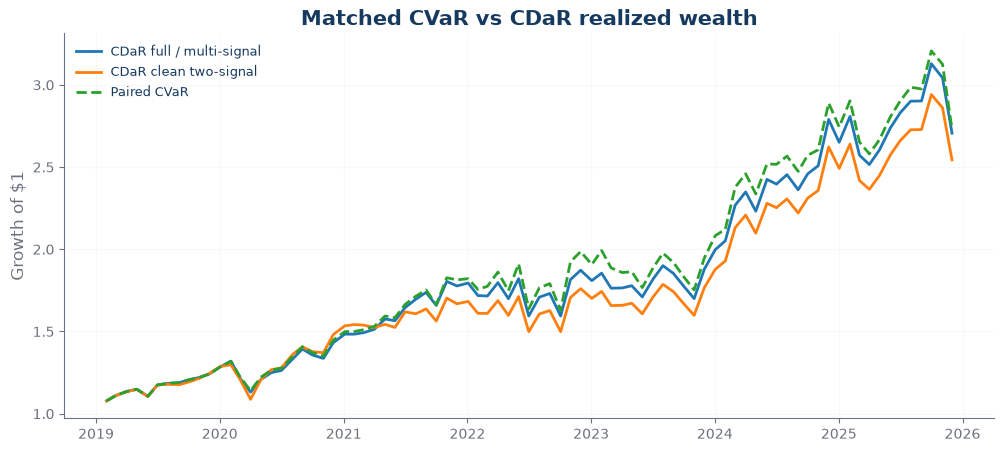

In [53]:
CVAR_FOLDER="bayessian_cvar_paired_walk_forward"
cvar=load_pnl(CVAR_FOLDER)
if cvar is None:
    print("Paired CVaR run not found. Run scripts/configs/bayessian_cvar_paired.yaml to activate this section.")
else:
    rows={label:calc_metrics(d["pnl"]) for label,d in loaded.items()}
    rows["Paired CVaR"]=calc_metrics(cvar)
    display(pd.DataFrame(rows).T.round(4))

    fig,ax=plt.subplots(figsize=(12,5))
    for label,d in loaded.items():
        r=d["pnl"]["Returns"].dropna(); r=r.iloc[1:] if len(r) and abs(r.iloc[0])<1e-15 else r
        ax.plot(r.index,(1+r).cumprod(),label=label,lw=2)
    r=cvar["Returns"].dropna(); r=r.iloc[1:] if len(r) and abs(r.iloc[0])<1e-15 else r
    ax.plot(r.index,(1+r).cumprod(),label="Paired CVaR",lw=2,ls="--")
    ax.set_title("Matched CVaR vs CDaR realized wealth"); ax.set_ylabel("Growth of $1"); ax.grid(alpha=.25); ax.legend(); plt.show()


## 16. Export notebook summary tables

In [54]:
OUT=RESULTS/"cdar_notebook_analysis"
OUT.mkdir(parents=True,exist_ok=True)
if loaded:
    perf=pd.DataFrame({label:calc_metrics(d["pnl"]) for label,d in loaded.items()}).T
    perf.to_csv(OUT/"cdar_notebook_performance_summary.csv")
    print("Saved",OUT/"cdar_notebook_performance_summary.csv")

for label,d in loaded.items():
    f=RESULTS/d["folder"]/"forecast_risk.csv"
    if f.exists():
        x=pd.read_csv(f)
        cols=[c for c in ["date","cdar_model_raw","cdar_model_centered","cvar_model_centered","backward_vol_timer","forward_cdar_timer","forward_risk_timer","overlay_fraction"] if c in x]
        x[cols].to_csv(OUT/(d["folder"]+"_cdar_signal_summary.csv"),index=False)
print("Done.")


Saved /Users/mac/Downloads/Group_1/results/cdar_notebook_analysis/cdar_notebook_performance_summary.csv
Done.
